In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
from scipy.stats import pearsonr
import os
import locale
from pathlib import Path
# ---------------------------------------------------------------------------
# 1. Setup and Data Loading
# ---------------------------------------------------------------------------
# Mount Google Drive
drive.mount('/content/drive')

# Define folder paths
PROCESSED_DATA_FOLDER = Path("/content/drive/MyDrive/Resilient_Housing_Global_Regression/data_processed")
data_file_path = os.path.join(PROCESSED_DATA_FOLDER, "global_analysis_final_for_modeling.csv")

RESULTS_DATA_FOLDER = Path("/content/drive/MyDrive/Resilient_Housing_Global_Regression/Results")


df_analysis = pd.read_csv(data_file_path, encoding='utf-8-sig', low_memory=False)

dep_var = 'VULN_DEFAULT_ROBUSTNESS'
category_b_vars = [
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_DB_BUILDING_QUALITY_INDEX'
]
category_c_vars = ['DIS_EQK', 'DIS_STM', 'DIS_FLD']
all_vars = [dep_var] + category_b_vars + category_c_vars

# Create the fixed analysis sample (N=150)
df_stats = df_analysis.dropna(subset=all_vars).copy()

# Apply log transformations
log_map = {
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE': 'log_GDP',
    'DIS_EQK': 'log_DIS_EQK',
    'DIS_STM': 'log_DIS_STM',
    'DIS_FLD': 'log_DIS_FLD'
}
for original, new in log_map.items():
    df_stats[new] = np.log(df_stats[original] + 1)

print(f"✅ Analysis Sample Fixed: N = {len(df_stats)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Analysis Sample Fixed: N = 150


# Summary Statistics

In [25]:
# -----------------------------------------------------------------------------
# 2. SUMMARY STATISTICS CALCULATION
# -----------------------------------------------------------------------------

#Key variables to include in the summary stats
category_a_vars = ['VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY']
category_b_vars = [
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
    'log_GDP',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_DB_BUILDING_QUALITY_INDEX',
]
category_c_vars = [
    'DIS_EQK', 'log_DIS_EQK',
    'DIS_STM', 'log_DIS_STM',
    'DIS_FLD', 'log_DIS_FLD'
]


summary_vars = category_a_vars + category_b_vars + category_c_vars
summary_stats = df_stats[summary_vars].describe().T
summary_stats = summary_stats[['count', 'mean', 'std', 'min', 'max']]
summary_stats.columns = ['N', 'Mean', 'Std. Dev.', 'Min', 'Max']

# -----------------------------------------------------------------------------
# 3. FORMATTING AND DISPLAY
# -----------------------------------------------------------------------------

variable_label_map_en = {
    'VULN_DEFAULT_ROBUSTNESS': 'Combined Hazards (Robust or Medium)',
    'VULN_DEFAULT_ROBUST_ONLY': 'Combined Hazards (Robust Only)',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'Poverty Gap (%, $4.20/day, 2021 PPP)',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE': 'GDP per Capita (PPP, Intl $2021) - RAW',
    'log_GDP': 'Log GDP per Capita',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'Government Effectiveness (WGI, 2024)',
    'WB_DB_BUILDING_QUALITY_INDEX': 'Building Quality Index (0-15, Doing Business 2020)',
    'DIS_EQK': 'Earthquake Events (RAW)',
    'log_DIS_EQK': 'Log (Earthquake Events + 1)',
    'DIS_STM': 'Storm Events (RAW)',
    'log_DIS_STM': 'Log (Storm Events + 1)',
    'DIS_FLD': 'Flood Events (RAW)',
    'log_DIS_FLD': 'Log (Flood Events + 1)'
}

raw_variables_for_int_format = ['WB_GDP_PCAP_PPP_INTL_2021_VALUE', 'DIS_EQK', 'DIS_STM', 'DIS_FLD']

def format_summary_stats(df, label_map):
    formatted_rows = []

    for var_name in df.index:
        label = label_map.get(var_name, var_name)
        row = df.loc[var_name]


        fmt_row = {
            'Variable': label,
            'N': int(row['N'])
        }

        for col in ['Mean', 'Std. Dev.', 'Min', 'Max']:
            val = row[col]
            if var_name in raw_variables_for_int_format:
                fmt_row[col] = f"{val:,.0f}"
            else:
                fmt_row[col] = f"{val:.3f}"

        formatted_rows.append(fmt_row)

    return pd.DataFrame(formatted_rows).set_index('Variable')

formatted_stats = format_summary_stats(summary_stats, variable_label_map_en)


categories_to_print = [
    ('A. Housing Robustness Measures (Cost-Weighted Proportion)', category_a_vars),
    ('B. Socioeconomic and Governance Variables', category_b_vars),
    ('C. Disaster Experience (1990-2023, Event Counts)', category_c_vars)
]

title = f"Table 1: Summary Statistics for Regression Variables (N={len(df_stats)})"
divider = "=" * 100
print(f"{divider}\n{title}\n{divider}")
print(f"{'Variable':<55} | {'N':>4} | {'Mean':>10} | {'Std.Dev':>10} | {'Min':>10} | {'Max':>10} |")
print(":---|---:|---:|---:|---:|---:|")

for header, var_list in categories_to_print:
    print(f"**{header}** | | | | | |")
    for var in var_list:
        label = variable_label_map_en.get(var, var)
        if label in formatted_stats.index:
            row = formatted_stats.loc[label]
            print(f"{label:<55} | {int(row['N']):>4} | {row['Mean']:>10} | {row['Std. Dev.']:>10} | {row['Min']:>10} | {row['Max']:>10} |")

print(divider)

# -----------------------------------------------------------------------------
# 4. CSV EXPORT
# -----------------------------------------------------------------------------
export_df = summary_stats.copy()
export_df.index = export_df.index.map(lambda x: variable_label_map_en.get(x, x))
export_df.to_csv(export_file_path, encoding='utf-8-sig')
print(f"✅ Exported to: {export_file_path}")

Table 1: Summary Statistics for Regression Variables (N=150)
Variable                                                |    N |       Mean |    Std.Dev |        Min |        Max |
:---|---:|---:|---:|---:|---:|
**A. Housing Robustness Measures (Cost-Weighted Proportion)** | | | | | |
Combined Hazards (Robust or Medium)                     |  150 |      0.522 |      0.283 |      0.025 |      1.000 |
Combined Hazards (Robust Only)                          |  150 |      0.281 |      0.243 |      0.000 |      1.000 |
**B. Socioeconomic and Governance Variables** | | | | | |
Poverty Gap (%, $4.20/day, 2021 PPP)                    |  150 |      8.581 |     13.049 |      0.000 |     60.300 |
GDP per Capita (PPP, Intl $2021) - RAW                  |  150 |     23,733 |     24,884 |      1,036 |    130,049 |
Log GDP per Capita                                      |  150 |      9.502 |      1.155 |      6.944 |     11.776 |
Government Effectiveness (WGI, 2024)                    |  150 |     -0.05

# Sinle regression and scatter plot


!! NOTE: 'DIS_3_HAZARDS' column not found. Calculating it as the sum of EQK, STM, and FLD. !!

[Data Dropping Report]
Initial N: 217
Final N after cleaning: 150
Dropped Countries: 67

--- Dropped Countries with unavailable variables ---
【Aruba】 Missing: Poverty Gap at USD4.2PPP, Construction Quality Index, Log Earthquake Count, Log Storm Count, Log Flood Count, Log 3-Hazard Count Composite
【Afghanistan】 Missing: Poverty Gap at USD4.2PPP
【Andorra】 Missing: Poverty Gap at USD4.2PPP, Construction Quality Index, Log Earthquake Count, Log Storm Count, Log Flood Count, Log 3-Hazard Count Composite
【American Samoa】 Missing: Poverty Gap at USD4.2PPP, Construction Quality Index, Log GDP per Capita
【Antigua and Barbuda】 Missing: Poverty Gap at USD4.2PPP
【Azerbaijan】 Missing: Poverty Gap at USD4.2PPP
【Bahrain】 Missing: Poverty Gap at USD4.2PPP, Log Earthquake Count, Log Storm Count, Log Flood Count, Log 3-Hazard Count Composite
【Bahamas, The】 Missing: Poverty Gap at USD4.2PPP
【Bermuda】 Missing: 

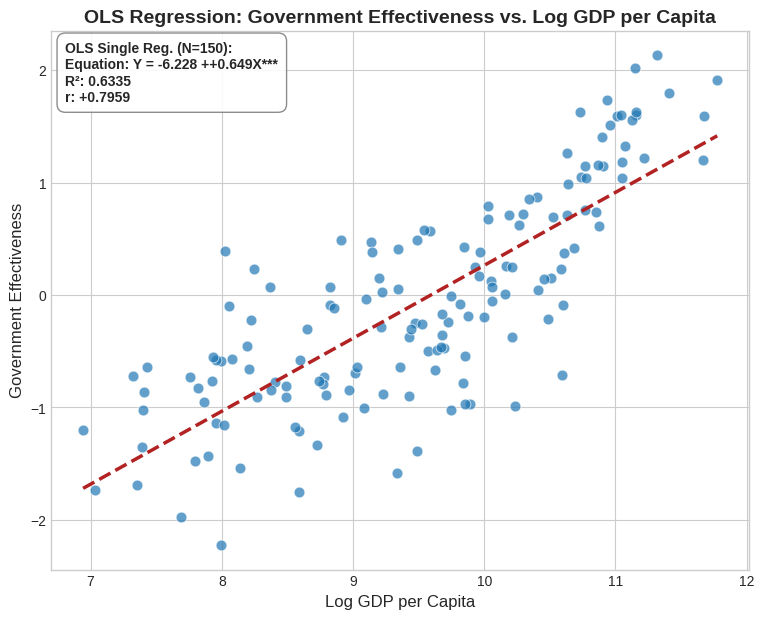

Summary for Government Effectiveness ~ Log GDP per Capita:
| Independent Variable   | Dependent Variable       | Coefficient (X)   |   R-squared |   Correlation (r) |   P-value (X) |   N |
|:-----------------------|:-------------------------|:------------------|------------:|------------------:|--------------:|----:|
| Log GDP per Capita     | Government Effectiveness | +0.6491***        |      0.6335 |            0.7959 |             0 | 150 |
Significance: * p<0.10, ** p<0.05, *** p<0.01
--------------------------------------------------------------------------------

### Standard Single Regression Analysis (IVs vs. Robustness DVs) ###

SUMMARY TABLE: Single Regression Results for DV: Building Robustness (Medium/High)
--------------------------------------------------------------------------------


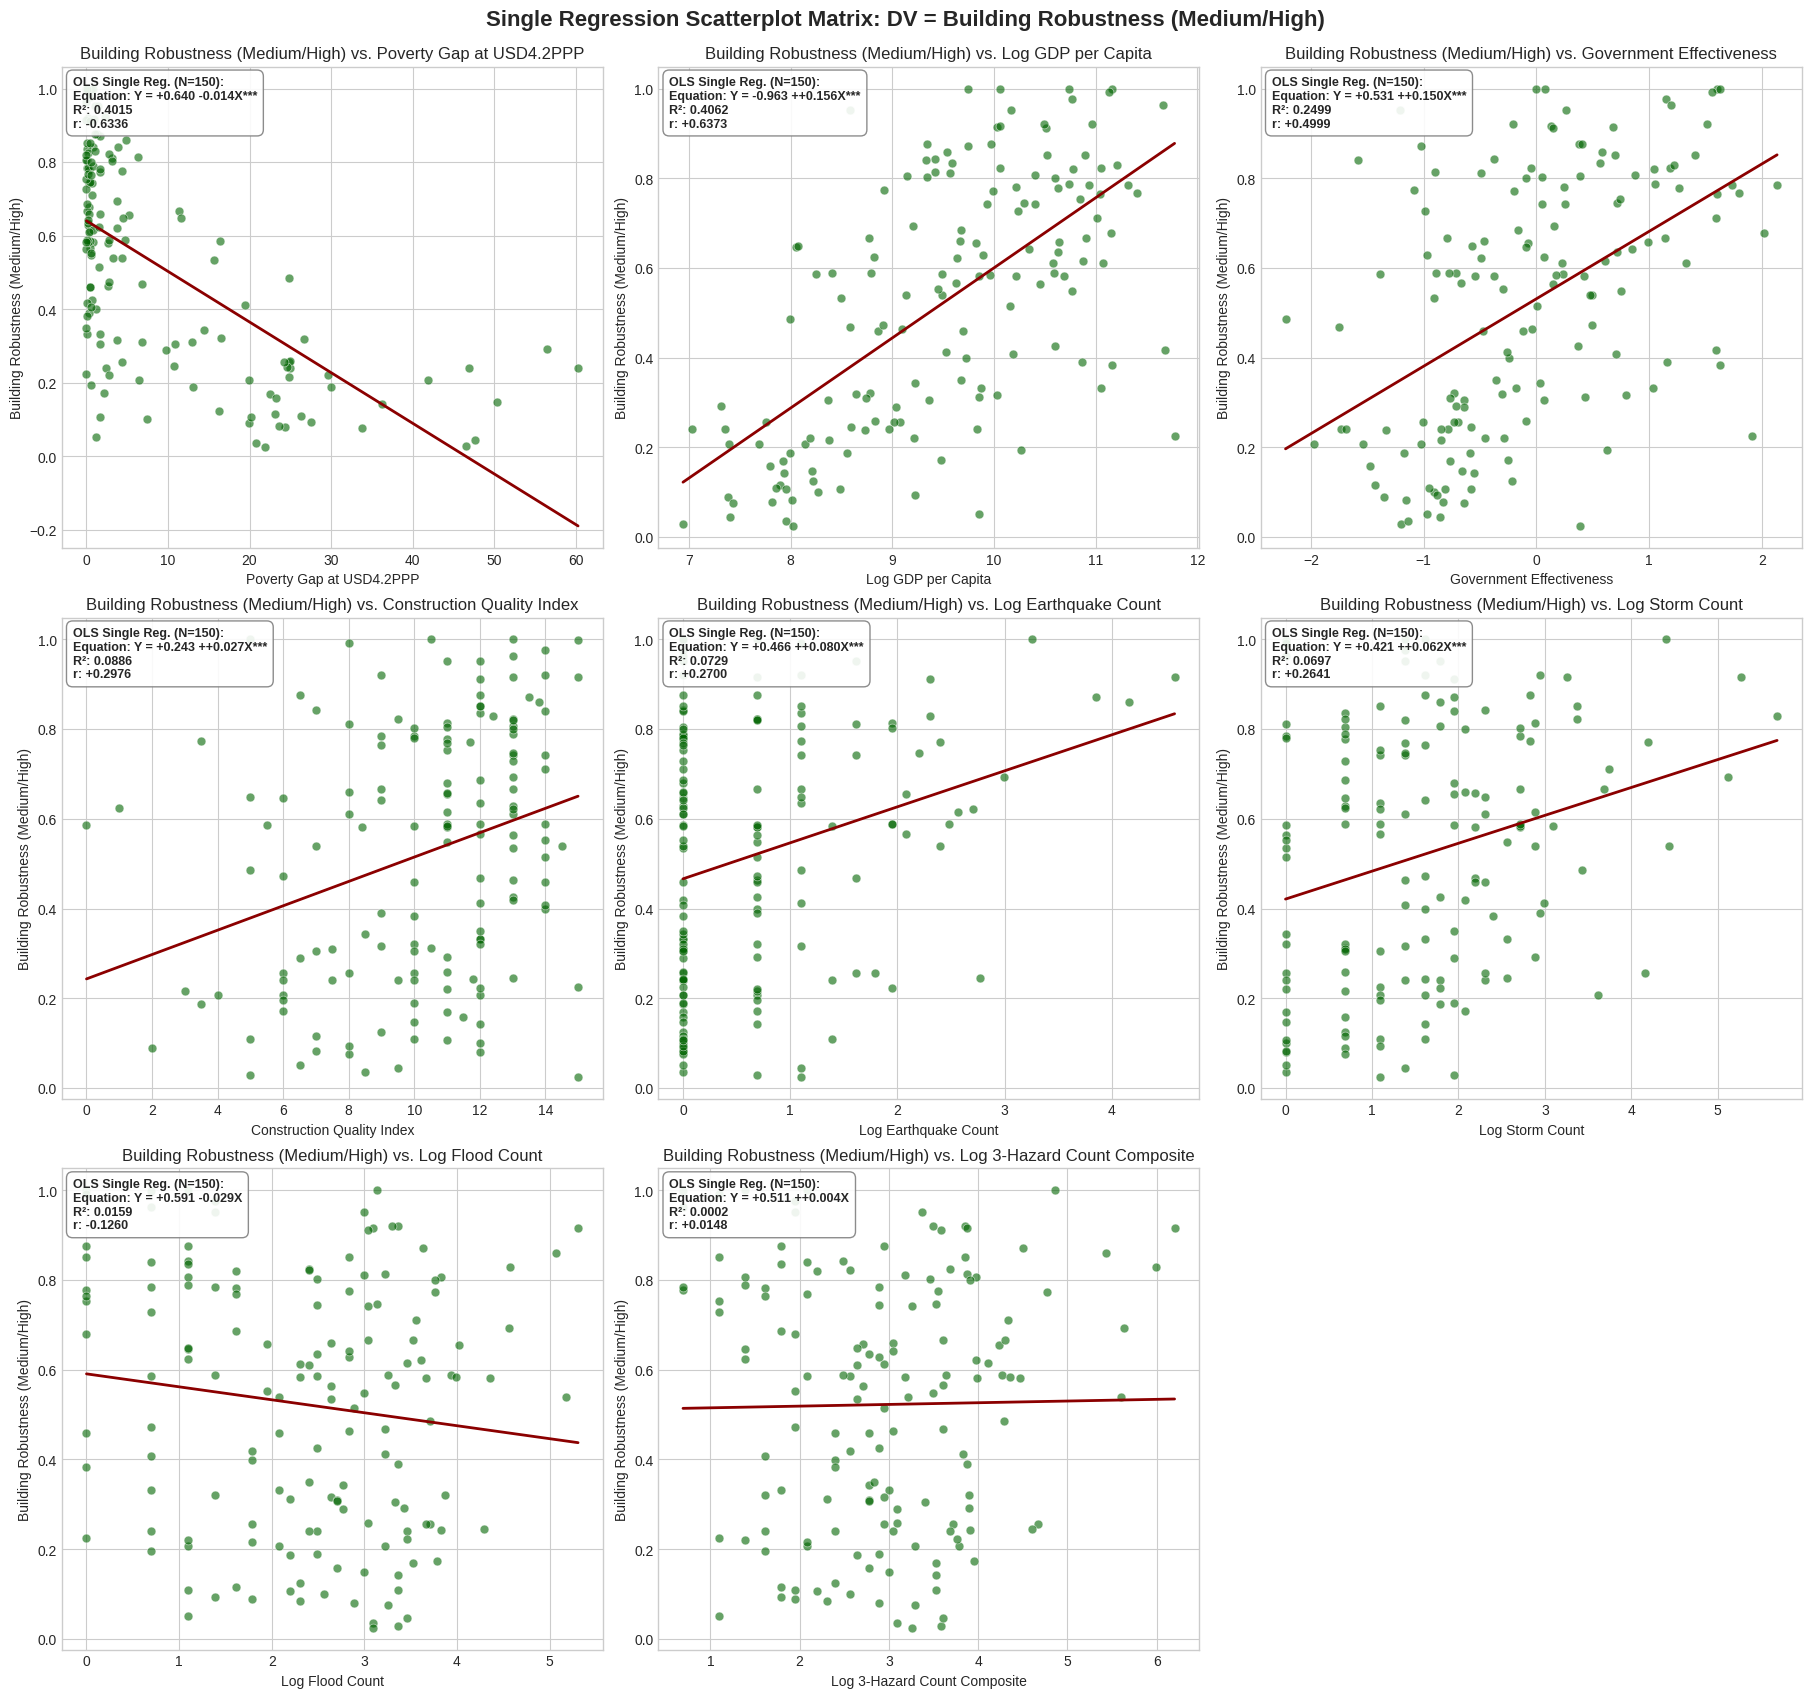

| Independent Variable         | Coefficient (X)   |   R-squared |   Correlation (r) |   P-value (X) |   N |
|:-----------------------------|:------------------|------------:|------------------:|--------------:|----:|
| Poverty Gap at USD4.2PPP     | -0.0138***        |      0.4015 |           -0.6336 |        0      | 150 |
| Log GDP per Capita           | +0.1563***        |      0.4062 |            0.6373 |        0      | 150 |
| Government Effectiveness     | +0.1503***        |      0.2499 |            0.4999 |        0      | 150 |
| Construction Quality Index   | +0.0272***        |      0.0886 |            0.2976 |        0.0002 | 150 |
| Log Earthquake Count         | +0.0803***        |      0.0729 |            0.27   |        0.0008 | 150 |
| Log Storm Count              | +0.0622***        |      0.0697 |            0.2641 |        0.0011 | 150 |
| Log Flood Count              | -0.0289           |      0.0159 |           -0.126  |        0.1245 | 150 |
| Log 3-Hazard Coun

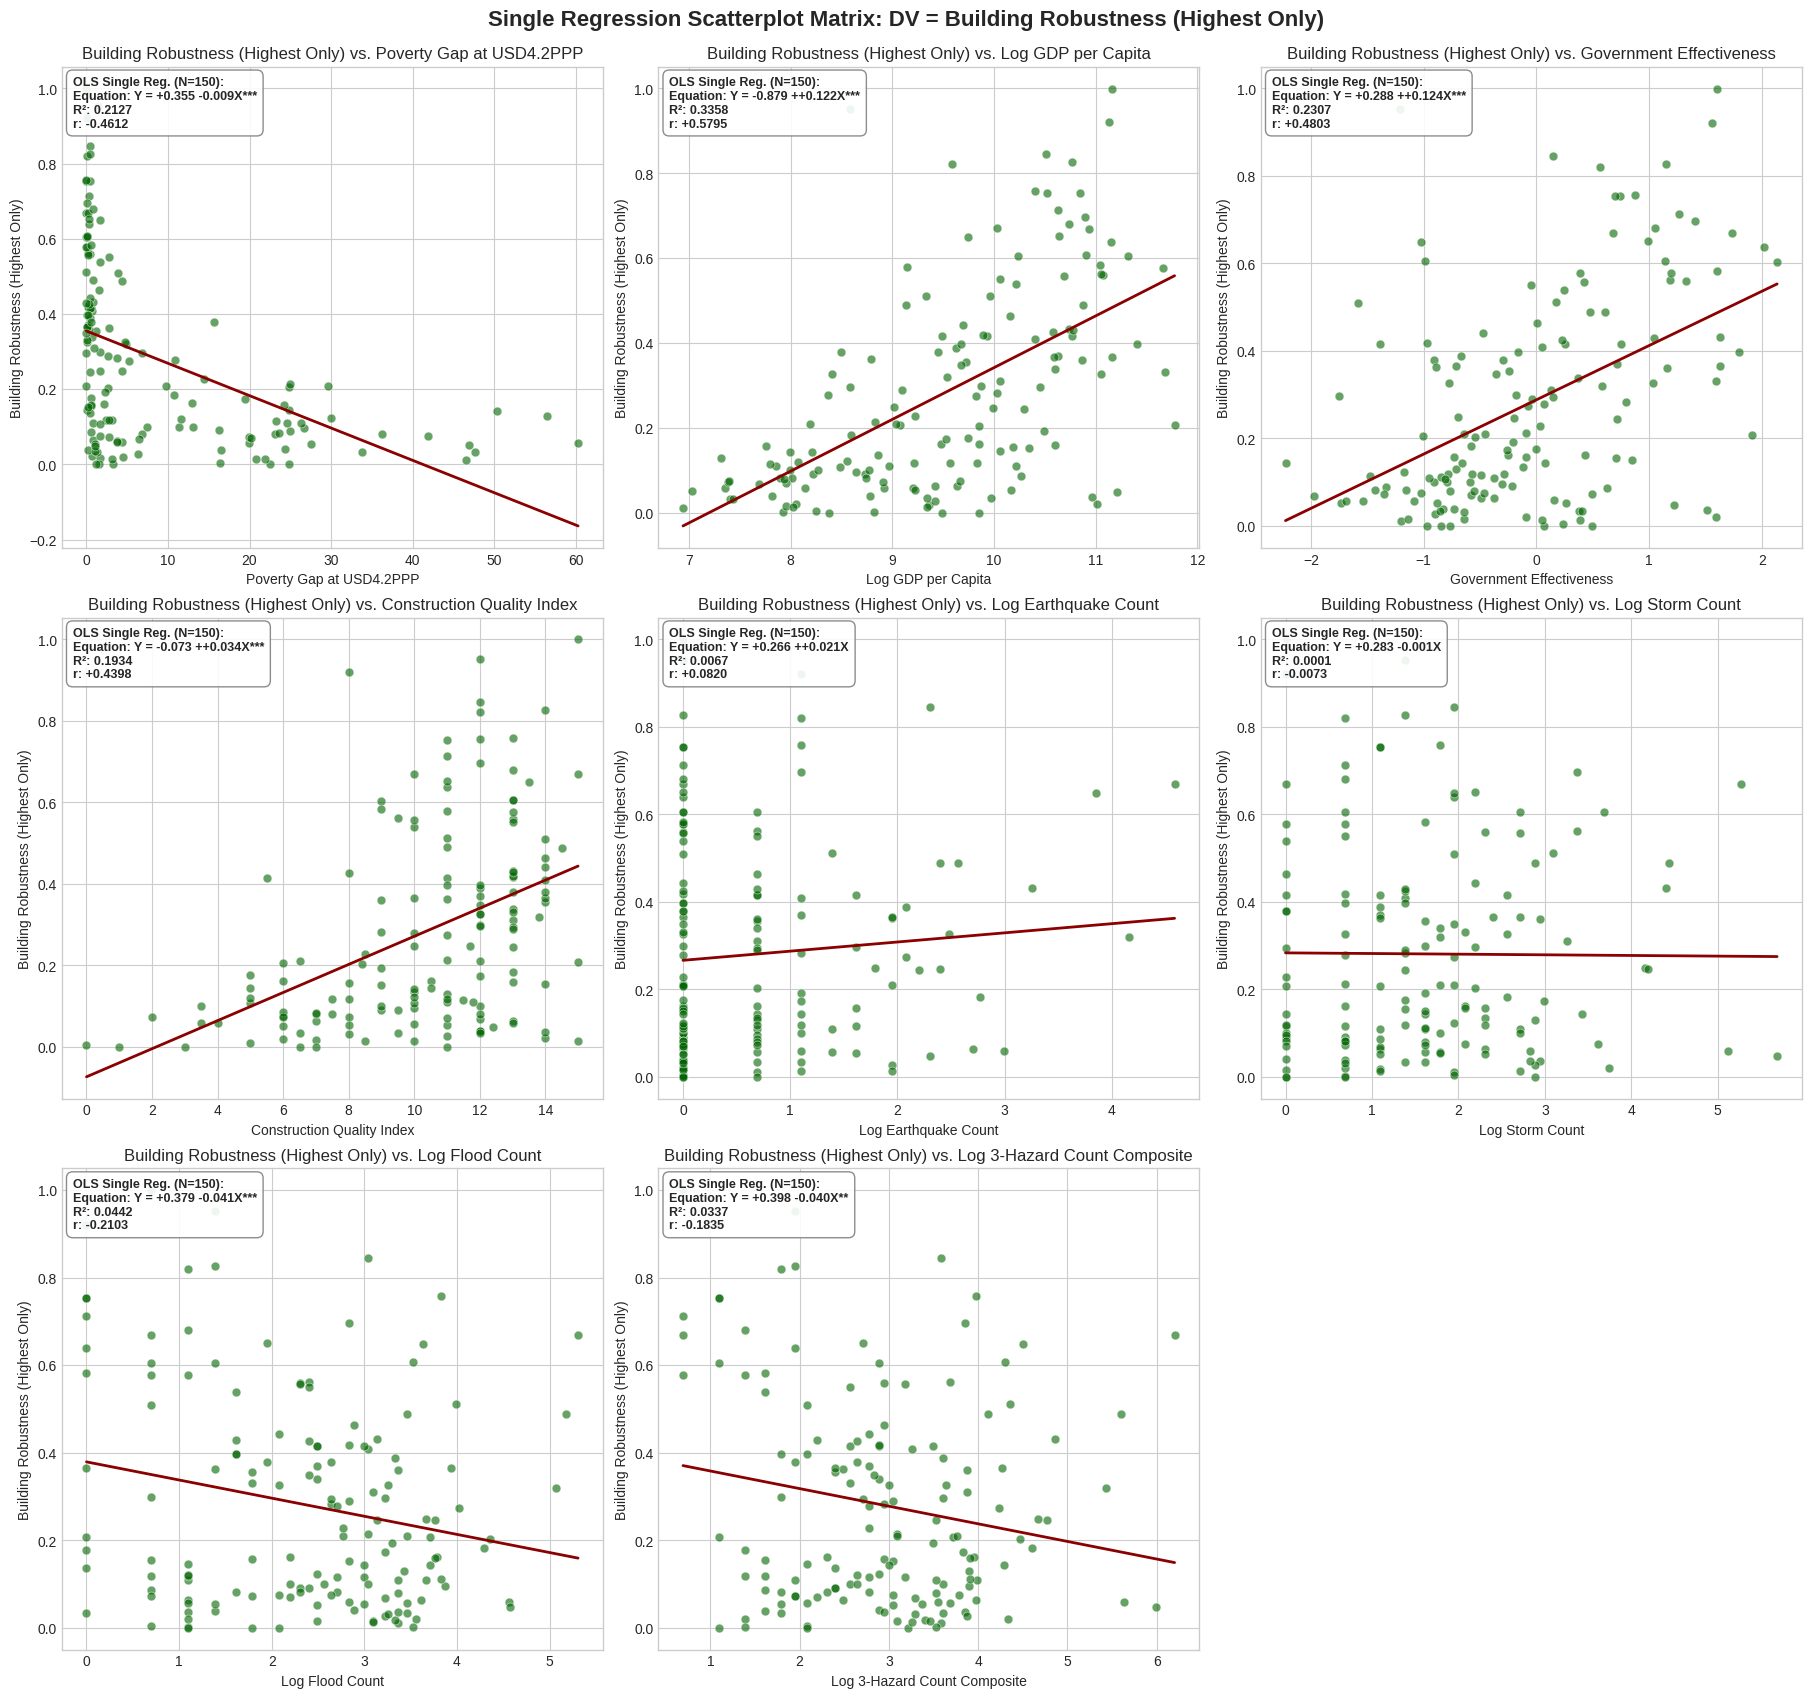

| Independent Variable         | Coefficient (X)   |   R-squared |   Correlation (r) |   P-value (X) |   N |
|:-----------------------------|:------------------|------------:|------------------:|--------------:|----:|
| Poverty Gap at USD4.2PPP     | -0.0086***        |      0.2127 |           -0.4612 |        0      | 150 |
| Log GDP per Capita           | +0.1220***        |      0.3358 |            0.5795 |        0      | 150 |
| Government Effectiveness     | +0.1240***        |      0.2307 |            0.4803 |        0      | 150 |
| Construction Quality Index   | +0.0345***        |      0.1934 |            0.4398 |        0      | 150 |
| Log Earthquake Count         | +0.0209           |      0.0067 |            0.082  |        0.3185 | 150 |
| Log Storm Count              | -0.0015           |      0.0001 |           -0.0073 |        0.929  | 150 |
| Log Flood Count              | -0.0414***        |      0.0442 |           -0.2103 |        0.0098 | 150 |
| Log 3-Hazard Coun

In [17]:
# Suppress harmless warnings for cleaner output
warnings.filterwarnings("ignore")

# Setting up pandas display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# for the script to run correctly.
df_single_regression = df_analysis.copy()

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# -----------------------------------------------------------------------------
# 0. Data Preparation and Feature Engineering
# -----------------------------------------------------------------------------

# --- CRITICAL FIX: Ensure DIS_3_HAZARDS is created if it does not exist ---
if 'DIS_3_HAZARDS' not in df_single_regression.columns:
    print("\n!! NOTE: 'DIS_3_HAZARDS' column not found. Calculating it as the sum of EQK, STM, and FLD. !!")
    df_single_regression['DIS_3_HAZARDS'] = df_single_regression[['DIS_EQK', 'DIS_STM', 'DIS_FLD']].sum(axis=1, skipna=False)


# --- 0-1. Log Transformation ---
df_single_regression['log_GDP'] = np.log(df_single_regression['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
df_single_regression['log_DIS_EQK'] = np.log1p(df_single_regression['DIS_EQK'])
df_single_regression['log_DIS_STM'] = np.log1p(df_single_regression['DIS_STM'])
df_single_regression['log_DIS_FLD'] = np.log1p(df_single_regression['DIS_FLD'])
df_single_regression['log_DIS_3_HAZARDS'] = np.log1p(df_single_regression['DIS_3_HAZARDS'])


# -----------------------------------------------------------------------------
# 1. Define Variables for Plotting
# -----------------------------------------------------------------------------

# Dependent Variables (Y-axis) - Note: These are Robustness/Quality Ratios
dv_map = {
    'VULN_DEFAULT_ROBUSTNESS': 'Building Robustness (Medium/High)',
    'VULN_DEFAULT_ROBUST_ONLY': 'Building Robustness (Highest Only)'
}

# Independent Variables (X-axis) - Including individual and composite disaster exposures
iv_map = {
    # Socio-Economic / Institutional
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'Poverty Gap at USD4.2PPP',
    'log_GDP': 'Log GDP per Capita',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'Government Effectiveness',
    'WB_DB_BUILDING_QUALITY_INDEX': 'Construction Quality Index',

    # Disaster Experience (COUNT BASE)
    'log_DIS_EQK': 'Log Earthquake Count',
    'log_DIS_STM': 'Log Storm Count',
    'log_DIS_FLD': 'Log Flood Count',
    'log_DIS_3_HAZARDS': 'Log 3-Hazard Count Composite',

}

# List of all required variables for the analysis
required_vars = [
    'VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY', 'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE', 'WB_DB_BUILDING_QUALITY_INDEX', 'log_GDP',

    # Counts
    'log_DIS_EQK', 'log_DIS_STM', 'log_DIS_FLD', 'log_DIS_3_HAZARDS',

]

# Ensure COUNTRY_NAME exists for reporting
if 'COUNTRY_NAME' not in df_single_regression.columns:
    print("\n!! WARNING: 'COUNTRY_NAME' column not found. Falling back to Index ID for report. !!")
    df_single_regression['COUNTRY_NAME'] = df_single_regression.index


# -----------------------------------------------------------------------------
# 2. Data Cleaning and Drop Report
# -----------------------------------------------------------------------------

# Filter required_vars to only include columns actually present in df_single_regression
present_required_vars = [v for v in required_vars if v in df_single_regression.columns]
if len(present_required_vars) < len(required_vars):
    print(f"\n!! NOTE: Not all required variables were found in the DataFrame. Analyzing with {len(present_required_vars)} variables. !!")
    required_vars = present_required_vars # Update the required_vars list

# Also filter iv_map to only use present columns
iv_map = {k: v for k, v in iv_map.items() if k in required_vars}

initial_n = len(df_single_regression)

# Identify rows with any missing data in the required subset
missing_data_mask = df_single_regression[required_vars].isna().any(axis=1)
countries_to_drop = df_single_regression[missing_data_mask]

# Perform dropping
df_single_regression.dropna(subset=required_vars, how='any', inplace=True)
final_n = len(df_single_regression)

# --- Output Drop Report ---
print("\n" + "=" * 80)
print("[Data Dropping Report]")
print("=" * 80)
print(f"Initial N: {initial_n}")
print(f"Final N after cleaning: {final_n}")
print(f"Dropped Countries: {initial_n - final_n}\n")

if initial_n > final_n:
    print("--- Dropped Countries with unavailable variables ---")

    # Iterate through the dropped countries and find the missing columns
    for index, row in countries_to_drop.iterrows():
        if index not in df_single_regression.index:
            country_name = row['COUNTRY_NAME']

            missing_cols = row[required_vars].isna()
            missing_vars = []

            for col in missing_cols[missing_cols].index.tolist():
                friendly_name = iv_map.get(col) or dv_map.get(col)

                if col == 'log_GDP':
                    missing_vars.append('Log GDP per Capita')
                elif col.startswith('log_DIS'):
                    missing_vars.append(friendly_name if friendly_name else col)
                elif friendly_name:
                    missing_vars.append(friendly_name)
                else:
                    missing_vars.append(col)

            if missing_vars:
                print(f"【{country_name}】 Missing: {', '.join(missing_vars)}")


print(f"✅ Data prepared for Scatterplot Analysis. Final sample size: {len(df_single_regression)}")


# -----------------------------------------------------------------------------
# 3. Plotting and Summary Function
# -----------------------------------------------------------------------------

def generate_scatterplots_and_summary(df, dv_col, dv_title, iv_map):
    """Generates a scatterplot matrix and a summary table for a single DV against multiple IVs."""

    num_ivs = len(iv_map)
    # Automatically adjust grid size: 3 columns max
    cols = 3
    rows = int(np.ceil(num_ivs / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5.5), constrained_layout=True)
    # Ensure axes is iterable even if it's a single axis (e.g., 1x1 plot)
    axes = np.atleast_2d(axes).flatten()

    summary_data = [] # List to store results for the summary table

    print("\n" + "=" * 80)
    print(f"SUMMARY TABLE: Single Regression Results for DV: {dv_title}")
    print("-" * 80)

    # Ensure a consistent N is used for all single regressions (the cleaned N)
    n_obs_cleaned = len(df)

    for i, (iv_col, iv_title) in enumerate(iv_map.items()):
        if i >= len(axes): # Safety break if more IVs than slots
            break

        ax = axes[i]

        # --- 3-1. Simple OLS Regression ---
        try:
            # Run OLS Regression
            model = smf.ols(formula=f'{dv_col} ~ {iv_col}', data=df).fit()

            # Extract key metrics
            coeff = model.params[iv_col]
            intercept = model.params['Intercept']
            r_squared = model.rsquared
            p_value = model.pvalues[iv_col]

            # Pearson correlation coefficient between the DV and IV
            correlation_r = df[dv_col].corr(df[iv_col])

            # Significance marker
            stars = ''
            if p_value < 0.01: stars = '***'
            elif p_value < 0.05: stars = '**'
            elif p_value < 0.10: stars = '*'

            # Create Regression Equation String for the plot
            # Ensure the signs are correctly handled in the equation string
            sign_str = '+' if coeff >= 0 else ''
            eq_str = (
                f'Y = {intercept:+.3f} {sign_str}{coeff:+.3f}X{stars}'
            )

            # Store data for summary table
            summary_data.append({
                'Independent Variable': iv_title,
                'DV': dv_title,
                'N': n_obs_cleaned,
                'Coefficient (X)': f'{coeff:+.4f}{stars}',
                'R-squared': f'{r_squared:.4f}',
                'Correlation (r)': f'{correlation_r:+.4f}', # 【修正】相関係数 r を追加
                'P-value (X)': f'{p_value:.4f}',
            })

            # --- 3-2. Plotting ---
            sns.scatterplot(x=iv_col, y=dv_col, data=df, ax=ax, alpha=0.6, color='#006400', s=40, edgecolor='w')

            # Add Regression Line
            df['predicted'] = model.predict(df)
            sns.lineplot(x=iv_col, y='predicted', data=df, ax=ax, color='darkred', linewidth=2, linestyle='-')
            df.drop(columns=['predicted'], inplace=True, errors='ignore')

            # Set Titles and Labels
            ax.set_title(f'{dv_title} vs. {iv_title}', fontsize=12)
            ax.set_xlabel(iv_title, fontsize=10)
            ax.set_ylabel(dv_title, fontsize=10)

            # Add Regression Metrics to the Plot (Top Left)
            ax.text(0.02, 0.98,
                    f'OLS Single Reg. (N={n_obs_cleaned}):\n'
                    f'Equation: {eq_str}\n'
                    f'R²: {r_squared:.4f}\n'
                    f'r: {correlation_r:+.4f}',
                    transform=ax.transAxes,
                    fontsize=9,
                    verticalalignment='top',
                    fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.9, ec="gray"))

        except Exception as e:
            ax.set_title(f'ERROR: Cannot plot {iv_col}', fontsize=12)
            ax.text(0.5, 0.5, f"Analysis failed: {e}", transform=ax.transAxes, ha='center')
            summary_data.append({'Independent Variable': iv_title, 'DV': dv_title, 'N': n_obs_cleaned, 'Coefficient (X)': 'N/A', 'R-squared': 'N/A', 'Correlation (r)': 'N/A', 'P-value (X)': 'N/A'})


    # Hide any unused subplots
    for j in range(num_ivs, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Single Regression Scatterplot Matrix: DV = {dv_title}', fontsize=16, y=1.02, fontweight='bold')
    plt.show()

    # Print the summary table in markdown format for easy viewing in Jupyter
    summary_df = pd.DataFrame(summary_data)

    print(summary_df[['Independent Variable', 'Coefficient (X)', 'R-squared', 'Correlation (r)', 'P-value (X)', 'N']].to_markdown(index=False))
    print("=" * 80)
    print("Significance: * p<0.10, ** p<0.05, *** p<0.01")

def plot_specific_bivariate_regression(df):
    """
    Runs a single OLS regression of Government Effectiveness on Log GDP per Capita
    and generates a dedicated scatterplot with regression line.
    """
    x_col = 'log_GDP'
    x_title = 'Log GDP per Capita'
    y_col = 'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'
    y_title = 'Government Effectiveness'

    if x_col not in df.columns or y_col not in df.columns:
        print(f"\n!! ERROR: One or both variables ({x_col}, {y_col}) missing for specific plot. !!")
        return

    n_obs = len(df)

    print("\n" + "#" * 80)
    print(f"### DEDICATED ANALYSIS: {y_title} regressed on {x_title} ###")
    print("#" * 80)

    try:
        # Run OLS Regression
        model = smf.ols(formula=f'{y_col} ~ {x_col}', data=df).fit()

        # Extract key metrics
        coeff = model.params[x_col]
        intercept = model.params['Intercept']
        r_squared = model.rsquared
        p_value = model.pvalues[x_col]

        correlation_r = df[y_col].corr(df[x_col])

        # Significance marker
        stars = ''
        if p_value < 0.01: stars = '***'
        elif p_value < 0.05: stars = '**'
        elif p_value < 0.10: stars = '*'

        # Create Regression Equation String for the plot
        sign_str = '+' if coeff >= 0 else ''
        eq_str = (
            f'Y = {intercept:+.3f} {sign_str}{coeff:+.3f}X{stars}'
        )

        # --- Plotting ---
        plt.figure(figsize=(9, 7))
        ax = plt.gca()

        sns.scatterplot(x=x_col, y=y_col, data=df, ax=ax, alpha=0.7, color='#1f77b4', s=60, edgecolor='w')

        # Add Regression Line
        df['predicted'] = model.predict(df)
        sns.lineplot(x=x_col, y='predicted', data=df, ax=ax, color='firebrick', linewidth=2.5, linestyle='--')
        df.drop(columns=['predicted'], inplace=True, errors='ignore')

        # Set Titles and Labels
        ax.set_title(f'OLS Regression: {y_title} vs. {x_title}', fontsize=14, fontweight='bold')
        ax.set_xlabel(x_title, fontsize=12)
        ax.set_ylabel(y_title, fontsize=12)

        # Add Regression Metrics to the Plot (Top Left)
        ax.text(0.02, 0.98,
                f'OLS Single Reg. (N={n_obs}):\n'
                f'Equation: {eq_str}\n'
                f'R²: {r_squared:.4f}\n'
                f'r: {correlation_r:+.4f}',
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='top',
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.6", fc="white", alpha=0.9, ec="gray", lw=1))

        plt.show()

        # Print Summary Table
        print(f"Summary for {y_title} ~ {x_title}:")
        summary_data = pd.DataFrame([{
            'Independent Variable': x_title,
            'Dependent Variable': y_title,
            'N': n_obs,
            'Coefficient (X)': f'{coeff:+.4f}{stars}',
            'R-squared': f'{r_squared:.4f}',
            'Correlation (r)': f'{correlation_r:+.4f}',
            'P-value (X)': f'{p_value:.4f}',
        }])
        print(summary_data[['Independent Variable', 'Dependent Variable', 'Coefficient (X)', 'R-squared', 'Correlation (r)', 'P-value (X)', 'N']].to_markdown(index=False))
        print("Significance: * p<0.10, ** p<0.05, *** p<0.01")
        print("-" * 80)

    except Exception as e:
        print(f"\n!! ERROR: Specific Bivariate Analysis failed: {e} !!")


# -----------------------------------------------------------------------------
# 4. Execution
# -----------------------------------------------------------------------------

plot_specific_bivariate_regression(df_single_regression)
print("\n" + "="*80)
print("### Standard Single Regression Analysis (IVs vs. Robustness DVs) ###")
print("="*80)



# -----------------------------------------------------------------------------
# 4. Execution
# -----------------------------------------------------------------------------

# VULN (Medium/High Robustness)
generate_scatterplots_and_summary(df_single_regression,
                                 'VULN_DEFAULT_ROBUSTNESS',
                                 dv_map['VULN_DEFAULT_ROBUSTNESS'],
                                 iv_map)

# ONLY (Highest Robustness Only)
generate_scatterplots_and_summary(df_single_regression,
                                 'VULN_DEFAULT_ROBUST_ONLY',
                                 dv_map['VULN_DEFAULT_ROBUST_ONLY'],
                                 iv_map)

# Correlation matrix

In [18]:
# -----------------------------------------------------------------------------
# 1. PREPARE DATA AND CREATE LOG TRANSFORMATIONS
# -----------------------------------------------------------------------------

# Create a copy of the analysis dataframe
df_corr = df_analysis.copy()

# --- CREATE LOG TRANSFORMATIONS FIRST ---
print(f"\n{'='*80}")
print(f"PREPARING DATA FOR CORRELATION MATRIX")
print(f"{'='*80}")

# Log GDP
if 'log_GDP' not in df_corr.columns:
    df_corr['log_GDP'] = np.log(df_corr['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
    print("✅ Created: log_GDP")

# Create DIS_3_HAZARDS if it doesn't exist
if 'DIS_3_HAZARDS' not in df_corr.columns:
    df_corr['DIS_3_HAZARDS'] = df_corr[['DIS_EQK', 'DIS_STM', 'DIS_FLD']].sum(axis=1, skipna=False)
    print("✅ Created: DIS_3_HAZARDS")

# Log disaster variables
if 'log_DIS_EQK' not in df_corr.columns:
    df_corr['log_DIS_EQK'] = np.log1p(df_corr['DIS_EQK'])
    print("✅ Created: log_DIS_EQK")

if 'log_DIS_STM' not in df_corr.columns:
    df_corr['log_DIS_STM'] = np.log1p(df_corr['DIS_STM'])
    print("✅ Created: log_DIS_STM")

if 'log_DIS_FLD' not in df_corr.columns:
    df_corr['log_DIS_FLD'] = np.log1p(df_corr['DIS_FLD'])
    print("✅ Created: log_DIS_FLD")

if 'log_DIS_3_HAZARDS' not in df_corr.columns:
    df_corr['log_DIS_3_HAZARDS'] = np.log1p(df_corr['DIS_3_HAZARDS'])
    print("✅ Created: log_DIS_3_HAZARDS")

print(f"{'='*80}\n")


# Define variables for correlation matrix (matching your regression variables)
correlation_vars = [
    # Dependent Variables
    'VULN_DEFAULT_ROBUSTNESS',
    'VULN_DEFAULT_ROBUST_ONLY',

    # Socioeconomic Variables
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'log_GDP',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_DB_BUILDING_QUALITY_INDEX',

    # Disaster Exposure Variables (Log-transformed)
    'log_DIS_EQK',
    'log_DIS_STM',
    'log_DIS_FLD',
    'log_DIS_3_HAZARDS'
]

# Create clean dataset (same as regression sample)
df_corr = df_corr[correlation_vars].dropna()

print(f"\n{'='*80}")
print(f"CORRELATION MATRIX ANALYSIS")
print(f"{'='*80}")
print(f"Sample Size (N): {len(df_corr)}")
print(f"Number of Variables: {len(correlation_vars)}")
print(f"{'='*80}\n")


# -----------------------------------------------------------------------------
# 2. VARIABLE LABELS FOR DISPLAY
# -----------------------------------------------------------------------------

# Short labels for correlation matrix (to fit in table)
corr_labels_short = {
    'VULN_DEFAULT_ROBUSTNESS': '(1) Robustness (Med/High)',
    'VULN_DEFAULT_ROBUST_ONLY': '(2) Robustness (High Only)',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': '(3) Poverty Gap',
    'log_GDP': '(4) Log GDP p.c.',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': '(5) Gov. Effectiveness',
    'WB_DB_BUILDING_QUALITY_INDEX': '(6) Building Quality',
    'log_DIS_EQK': '(7) Log Earthquake',
    'log_DIS_STM': '(8) Log Storm',
    'log_DIS_FLD': '(9) Log Flood',
    'log_DIS_3_HAZARDS': '(10) Log 3-Hazards'
}

# Full labels for legend/notes
corr_labels_full = {
    'VULN_DEFAULT_ROBUSTNESS': 'Building Robustness (Medium/High)',
    'VULN_DEFAULT_ROBUST_ONLY': 'Building Robustness (High Only)',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'Poverty Gap at $4.20/day (2021 PPP)',
    'log_GDP': 'Log GDP per Capita (PPP)',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'Government Effectiveness (WGI)',
    'WB_DB_BUILDING_QUALITY_INDEX': 'Building Quality Index (0-15)',
    'log_DIS_EQK': 'Log Earthquake Count (1990-2023)',
    'log_DIS_STM': 'Log Storm Count (1990-2023)',
    'log_DIS_FLD': 'Log Flood Count (1990-2023)',
    'log_DIS_3_HAZARDS': 'Log Combined Hazards (EQK+STM+FLD)'
}


# -----------------------------------------------------------------------------
# 3. CALCULATE CORRELATION MATRIX WITH SIGNIFICANCE
# -----------------------------------------------------------------------------

def calculate_correlation_with_pvalues(df, variables):
    """
    Calculate Pearson correlation matrix with p-values.
    Returns correlation matrix and p-value matrix.
    """
    n_vars = len(variables)
    corr_matrix = np.zeros((n_vars, n_vars))
    pval_matrix = np.zeros((n_vars, n_vars))

    for i, var1 in enumerate(variables):
        for j, var2 in enumerate(variables):
            if i == j:
                corr_matrix[i, j] = 1.0
                pval_matrix[i, j] = 0.0
            else:
                corr, pval = pearsonr(df[var1].dropna(), df[var2].dropna())
                corr_matrix[i, j] = corr
                pval_matrix[i, j] = pval

    return corr_matrix, pval_matrix

# Calculate correlations
corr_matrix, pval_matrix = calculate_correlation_with_pvalues(df_corr, correlation_vars)

# Create DataFrames with proper labels
corr_df = pd.DataFrame(
    corr_matrix,
    index=[corr_labels_short[v] for v in correlation_vars],
    columns=[corr_labels_short[v] for v in correlation_vars]
)

pval_df = pd.DataFrame(
    pval_matrix,
    index=[corr_labels_short[v] for v in correlation_vars],
    columns=[corr_labels_short[v] for v in correlation_vars]
)


# -----------------------------------------------------------------------------
# 4. CREATE FORMATTED CORRELATION TABLE WITH SIGNIFICANCE STARS
# -----------------------------------------------------------------------------

def format_correlation_with_stars(corr_val, pval):
    """Format correlation coefficient with significance stars."""
    if np.isnan(corr_val):
        return '-'

    # Add significance stars
    stars = ''
    if pval < 0.01:
        stars = '***'
    elif pval < 0.05:
        stars = '**'
    elif pval < 0.10:
        stars = '*'

    return f'{corr_val:.3f}{stars}'


# -----------------------------------------------------------------------------
# 5. CREATE FULL MATRIX (FOR REFERENCE)
# -----------------------------------------------------------------------------

# Create formatted full correlation matrix
formatted_corr_full = pd.DataFrame(
    index=corr_df.index,
    columns=corr_df.columns
)

for i in range(len(corr_df)):
    for j in range(len(corr_df.columns)):
        formatted_corr_full.iloc[i, j] = format_correlation_with_stars(
            corr_df.iloc[i, j],
            pval_df.iloc[i, j]
        )

print("\n" + "="*120)
print("FULL CORRELATION MATRIX (ALL CELLS)")
print("="*120)
print(f"(N = {len(df_corr)})")
print("-"*120)
print(formatted_corr_full.to_string())
print("-"*120)
print("Notes: Pearson correlation coefficients reported.")
print("Significance levels: * p<0.10, ** p<0.05, *** p<0.01")
print("="*120)


# -----------------------------------------------------------------------------
# 6. CREATE LOWER TRIANGLE VERSION (PUBLICATION FORMAT)
# -----------------------------------------------------------------------------

def create_lower_triangle_correlation(corr_df, pval_df):
    """
    Create lower triangle correlation matrix (standard format for publications).
    """
    formatted_lower = pd.DataFrame(
        index=corr_df.index,
        columns=corr_df.columns,
        data=''
    )

    for i in range(len(corr_df)):
        for j in range(i + 1):  # Only lower triangle including diagonal
            formatted_lower.iloc[i, j] = format_correlation_with_stars(
                corr_df.iloc[i, j],
                pval_df.iloc[i, j]
            )

    return formatted_lower

# Create lower triangle version
formatted_corr_lower = create_lower_triangle_correlation(corr_df, pval_df)

print("\n" + "="*120)
print("LOWER TRIANGLE CORRELATION MATRIX (PUBLICATION FORMAT)")
print("="*120)
print(f"(N = {len(df_corr)})")
print("-"*120)
print(formatted_corr_lower.to_string())
print("-"*120)
print("Notes: Pearson correlation coefficients reported. Lower triangle only.")
print("Significance levels: * p<0.10, ** p<0.05, *** p<0.10")
print("="*120)


# -----------------------------------------------------------------------------
# 7. CREATE VARIABLE LEGEND TABLE
# -----------------------------------------------------------------------------

# Create legend for variable numbers
legend_df = pd.DataFrame([
    {'Number': f'({i+1})', 'Variable': corr_labels_full[var]}
    for i, var in enumerate(correlation_vars)
])

print("\n" + "="*120)
print("VARIABLE LEGEND FOR CORRELATION MATRIX")
print("="*120)
print(legend_df.to_string(index=False))
print("="*120)


# -----------------------------------------------------------------------------
# 8. EXPORT TO CSV
# -----------------------------------------------------------------------------

# Export 1: Full correlation matrix
export_corr_full_path = os.path.join(RESULTS_DATA_FOLDER, "correlation_matrix_full.csv")
formatted_corr_full.to_csv(export_corr_full_path, encoding='utf-8')
print(f"\n✅ Full correlation matrix exported to: {export_corr_full_path}")

# Export 2: Lower triangle (publication format)
export_corr_lower_path = os.path.join(RESULTS_DATA_FOLDER, "correlation_matrix_publication.csv")
formatted_corr_lower.to_csv(export_corr_lower_path, encoding='utf-8')
print(f"✅ Publication format (lower triangle) exported to: {export_corr_lower_path}")

# Export 3: Variable legend
legend_path = os.path.join(RESULTS_DATA_FOLDER, "correlation_matrix_legend.csv")
legend_df.to_csv(legend_path, index=False, encoding='utf-8')
print(f"✅ Variable legend exported to: {legend_path}")


# -----------------------------------------------------------------------------
# 9. SUMMARY STATISTICS FOR KEY CORRELATIONS
# -----------------------------------------------------------------------------

print("\n" + "="*120)
print("KEY CORRELATION HIGHLIGHTS")
print("="*120)

# Identify strongest correlations (excluding diagonal)
strong_corr = []
for i in range(len(correlation_vars)):
    for j in range(i+1, len(correlation_vars)):
        corr_val = corr_matrix[i, j]
        pval = pval_matrix[i, j]
        if abs(corr_val) > 0.3 and pval < 0.05:  # Threshold for "strong"
            strong_corr.append({
                'Variable 1': corr_labels_short[correlation_vars[i]],
                'Variable 2': corr_labels_short[correlation_vars[j]],
                'Correlation': corr_val,
                'P-value': pval,
                'Formatted': format_correlation_with_stars(corr_val, pval)
            })

# Sort by absolute correlation
strong_corr_df = pd.DataFrame(strong_corr)
if len(strong_corr_df) > 0:
    strong_corr_df['Abs_Corr'] = strong_corr_df['Correlation'].abs()
    strong_corr_df = strong_corr_df.sort_values('Abs_Corr', ascending=False)

    print("\nStrongest Correlations (|r| > 0.3, p < 0.05):")
    print("-"*120)
    print(strong_corr_df[['Variable 1', 'Variable 2', 'Formatted']].to_string(index=False))
else:
    print("\nNo correlations exceed |r| > 0.3 with p < 0.05")

print("="*120)

print("\n✅ Correlation matrix analysis complete!")
print(f"\n📁 EXPORTED FILES:")
print(f"   1. Full matrix: {export_corr_full_path}")
print(f"   2. Publication format: {export_corr_lower_path}")
print(f"   3. Variable legend: {legend_path}")



PREPARING DATA FOR CORRELATION MATRIX
✅ Created: log_GDP
✅ Created: DIS_3_HAZARDS
✅ Created: log_DIS_EQK
✅ Created: log_DIS_STM
✅ Created: log_DIS_FLD
✅ Created: log_DIS_3_HAZARDS


CORRELATION MATRIX ANALYSIS
Sample Size (N): 150
Number of Variables: 10


FULL CORRELATION MATRIX (ALL CELLS)
(N = 150)
------------------------------------------------------------------------------------------------------------------------
                           (1) Robustness (Med/High) (2) Robustness (High Only) (3) Poverty Gap (4) Log GDP p.c. (5) Gov. Effectiveness (6) Building Quality (7) Log Earthquake (8) Log Storm (9) Log Flood (10) Log 3-Hazards
(1) Robustness (Med/High)                   1.000***                   0.570***       -0.634***         0.637***               0.500***             0.298***           0.270***      0.264***        -0.126              0.015
(2) Robustness (High Only)                  0.570***                   1.000***       -0.461***         0.579***               0.

# Multiple regression (72 patterns)

In [ ]:
# Check list of World Bank Region
unique_regions = df_analysis['REGION'].unique()

# Print the list of unique regions
print(unique_regions)

['South Asia' 'Europe & Central Asia' 'Middle East & North Africa'
 'East Asia & Pacific' 'Sub-Saharan Africa' 'Latin America & Caribbean'
 'North America' nan]


In [ ]:
warnings.simplefilter(action='ignore', category=FutureWarning)

# -----------------------------------------------------------------------------
# 0. DATA PREPARATION AND PRE-PROCESSING
# -----------------------------------------------------------------------------
df_multi_regress = df_analysis.copy()

# --- 0-1. Hazard Index Creation ---
if 'DIS_FLD' not in df_multi_regress.columns: df_multi_regress['DIS_FLD'] = 0
if 'DIS_EQK' not in df_multi_regress.columns: df_multi_regress['DIS_EQK'] = 0
if 'DIS_STM' not in df_multi_regress.columns: df_multi_regress['DIS_STM'] = 0

df_multi_regress['DIS_EQK_STM'] = df_multi_regress['DIS_EQK'] + df_multi_regress['DIS_STM']
THREE_HAZARDS_VAR_NAME = 'DIS_3_HAZARDS'
df_multi_regress[THREE_HAZARDS_VAR_NAME] = df_multi_regress['DIS_EQK'] + df_multi_regress['DIS_STM'] + df_multi_regress['DIS_FLD']


required_vars = [
    'VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY',
    'VULN_EARTHQUAKE_ROBUSTNESS', 'VULN_EARTHQUAKE_ROBUST_ONLY',
    'VULN_WIND_ROBUSTNESS', 'VULN_WIND_ROBUST_ONLY',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE', 'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE', 'WB_DB_BUILDING_QUALITY_INDEX',
    'DIS_EQK', 'DIS_STM', 'DIS_EQK_STM', 'DIS_FLD', THREE_HAZARDS_VAR_NAME, 'VULN_WATER_ROBUSTNESS',
    'REGION'
]

missing_vars = [var for var in required_vars if var not in df_multi_regress.columns]

if missing_vars:
    raise ValueError(f"Error: Required variables missing: {', '.join(missing_vars)}")

df_multi_regress.dropna(subset=required_vars, how='any', inplace=True)
print(f"✅ Sample size after cleaning: {len(df_multi_regress)}\n")

# --- 0-2. Data Transformation ---

df_multi_regress['log_GDP'] = np.log(df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
df_multi_regress['log_DIS_EQK'] = np.log1p(df_multi_regress['DIS_EQK'])
df_multi_regress['log_DIS_STM'] = np.log1p(df_multi_regress['DIS_STM'])
df_multi_regress['log_DIS_EQK_STM'] = np.log1p(df_multi_regress['DIS_EQK_STM'])
df_multi_regress['log_DIS_FLD'] = np.log1p(df_multi_regress['DIS_FLD'])
df_multi_regress[f'log_{THREE_HAZARDS_VAR_NAME}'] = np.log1p(df_multi_regress[THREE_HAZARDS_VAR_NAME])

# Mean Centering

vars_to_center_map = {
    'log_GDP': 'C_log_GDP',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'C_CWGI',
    'WB_DB_BUILDING_QUALITY_INDEX': 'C_CDBQ',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'C_POVERTY',
    'log_DIS_EQK': 'C_log_DIS_EQK',
    'log_DIS_STM': 'C_log_DIS_STM',
    'log_DIS_EQK_STM': 'C_log_DIS_EQK_STM',
    'log_DIS_FLD': 'C_log_DIS_FLD',
    f'log_{THREE_HAZARDS_VAR_NAME}': f'C_log_{THREE_HAZARDS_VAR_NAME}'
}

for raw_var, centered_var_name in vars_to_center_map.items():
    df_multi_regress[centered_var_name] = df_multi_regress[raw_var] - df_multi_regress[raw_var].mean()

# poverty squared
df_multi_regress['C_POVERTY_SQ'] = df_multi_regress['C_POVERTY'] ** 2

print("✅ Log transformation, centering, and squared term creation completed.\n")

# -----------------------------------------------------------------------------
# 0-3. VIF DIAGNOSTICS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("VIF DIAGNOSTICS: Checking for Multicollinearity")
print("=" * 80)

vif_test_vars = ['C_POVERTY', 'C_log_GDP', 'C_CWGI', 'C_CDBQ']
vif_data = df_multi_regress[vif_test_vars].dropna()

vif_results = pd.DataFrame()
vif_results["Variable"] = vif_test_vars
vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_test_vars))]
print("\nVIF Results for Main Control Variables:")

print("-" * 50)
print(vif_results.to_string(index=False))
print("\nInterpretation:")
print("  VIF < 5: Low multicollinearity (acceptable)")
print("  VIF 5-10: Moderate multicollinearity (monitor)")
print("  VIF > 10: High multicollinearity (problematic)")

high_vif = vif_results[vif_results['VIF'] > 5]

if len(high_vif) > 0:
    print(f"\n⚠️ WARNING: {len(high_vif)} variable(s) show elevated VIF:")
    print(high_vif.to_string(index=False))
else:
    print("\n✅ All variables show acceptable VIF levels (< 5)")

print("\n" + "=" * 80)
print("CORRELATION MATRIX: Main Control Variables")
print("=" * 80)

corr_matrix = df_multi_regress[vif_test_vars].corr()
print(corr_matrix.round(3))
print("\n")


# -----------------------------------------------------------------------------
# 1. GENERIC OLS ANALYSIS FUNCTION
# -----------------------------------------------------------------------------

def run_ols_and_store(model_label: str, dependent_var: str, independent_vars: list, df: pd.DataFrame, fixed_effects: str = None):
    """Runs OLS regression with HC1 robust errors and returns the model object and metadata."""
    formula = f"{dependent_var} ~ {' + '.join(independent_vars)}"

    if fixed_effects:
        formula += f" + {fixed_effects}"
    try:
        model = smf.ols(formula=formula, data=df).fit(cov_type='HC1')
        return {
            'label': model_label,
            'model': model,
            'formula': formula,
            'DV': dependent_var,
        }

    except Exception as e:
        print(f"❌ WARNING: Model {model_label} failed. Details: {e}")
        return {'label': model_label, 'model': None, 'formula': formula, 'DV': dependent_var}

# -----------------------------------------------------------------------------
# 2. MODEL DEFINITION
# -----------------------------------------------------------------------------

all_models_results = []
REGION_FE = 'C(REGION)'

dependent_vars_list = [
    ('VULN_DEFAULT_ROBUSTNESS', 'VULN'),
    ('VULN_DEFAULT_ROBUST_ONLY', 'ONLY')
]

disaster_vars_list = [
    ('Earthquake Only (EQK)', 'C_log_DIS_EQK', 'J'),
    ('Storm Only (STM)', 'C_log_DIS_STM', 'K'),
    ('Earthquake + Storm (EQK+STM)', 'C_log_DIS_EQK_STM', 'L'),
    ('Flood Only (FLD)', 'C_log_DIS_FLD', 'N'),
    ('3 Hazards (EQK+STM+FLD)', f'C_log_{THREE_HAZARDS_VAR_NAME}', 'M'),
]

adjusting_vars_list = [
    ('Poverty', 'C_POVERTY'),
    ('GDP', 'C_log_GDP'),
    ('Governance', 'C_CWGI'),
    ('Building Reg.', 'C_CDBQ'),
]

print("\n" + "#" * 80)
print(f"# RUNNING SIMPLIFIED MODELS WITH REGIONAL FIXED EFFECTS ({REGION_FE})")
print("#" * 80)

for dv_raw, dv_label in dependent_vars_list:

    print(f"\n  Running {dv_label} baseline models...")

    base_vars_i1 = ['C_POVERTY', 'C_log_GDP']
    all_models_results.append(run_ols_and_store(f"{dv_label}-I.1", dv_raw, base_vars_i1, df_multi_regress, fixed_effects=REGION_FE))

    base_vars_i1_sq = base_vars_i1 + ['C_POVERTY_SQ']
    all_models_results.append(run_ols_and_store(f"{dv_label}-I.1-SQ", dv_raw, base_vars_i1_sq, df_multi_regress, fixed_effects=REGION_FE))

    base_vars_i2 = base_vars_i1 + ['C_CWGI']
    all_models_results.append(run_ols_and_store(f"{dv_label}-I.2", dv_raw, base_vars_i2, df_multi_regress, fixed_effects=REGION_FE))

    base_vars_i3 = base_vars_i2 + ['C_CDBQ']
    all_models_results.append(run_ols_and_store(f"{dv_label}-I.3", dv_raw, base_vars_i3, df_multi_regress, fixed_effects=REGION_FE))

    base_vars_i3_sq = base_vars_i3 + ['C_POVERTY_SQ']
    all_models_results.append(run_ols_and_store(f"{dv_label}-I.3-SQ", dv_raw, base_vars_i3_sq, df_multi_regress, fixed_effects=REGION_FE))

    # Disaster Models

    print(f"  Running {dv_label} disaster models...")

    for dis_label, c_disaster_var, base_model_char in disaster_vars_list:

        # Main Effect (X.1)
        independent_vars_main = base_vars_i1 + [c_disaster_var]
        model_label_main = f"{dv_label}-{base_model_char}.1"

        all_models_results.append(run_ols_and_store(model_label_main, dv_raw, independent_vars_main, df_multi_regress, fixed_effects=REGION_FE))

        # Interaction Models (X.2, X.3, X.4, X.5)

        for j, (adj_label, c_adjust_var) in enumerate(adjusting_vars_list):

            model_sub_index = j + 2
            model_label_int = f"{dv_label}-{base_model_char}.{model_sub_index}"

            independent_vars_int = base_vars_i1.copy()

            if c_adjust_var not in independent_vars_int:
                independent_vars_int.append(c_adjust_var)

            independent_vars_int.append(c_disaster_var)
            interaction_term = f'{c_adjust_var}:{c_disaster_var}'
            independent_vars_int.append(interaction_term)

            all_models_results.append(run_ols_and_store(model_label_int, dv_raw, independent_vars_int, df_multi_regress, fixed_effects=REGION_FE))

# Additional Hazard-Specific Models

print("\n  Running hazard-specific models...")

eqk_dvs = [
    ('VULN_EARTHQUAKE_ROBUSTNESS', 'EQK-R'),
    ('VULN_EARTHQUAKE_ROBUST_ONLY', 'EQK-RO')
]

for dv_raw, dv_label in eqk_dvs:
    base_vars_i1 = ['C_POVERTY', 'C_log_GDP']
    all_models_results.append(run_ols_and_store(f"{dv_label}-B.1", dv_raw, base_vars_i1, df_multi_regress))
    all_models_results.append(run_ols_and_store(f"{dv_label}-B.1", dv_raw, base_vars_i1, df_multi_regress, fixed_effects=REGION_FE))

    eqk_gdp_int_vars = ['C_POVERTY', 'C_log_GDP', 'C_log_DIS_EQK']
    all_models_results.append(run_ols_and_store(f"{dv_label}-J.3", dv_raw, eqk_gdp_int_vars, df_multi_regress))
    all_models_results.append(run_ols_and_store(f"{dv_label}-J.3", dv_raw, eqk_gdp_int_vars, df_multi_regress, fixed_effects=REGION_FE))

stm_dvs = [
    ('VULN_WIND_ROBUSTNESS', 'STM-R'),
    ('VULN_WIND_ROBUST_ONLY', 'STM-RO')
]

for dv_raw, dv_label in stm_dvs:

    base_vars_i1 = ['C_POVERTY', 'C_log_GDP']
    all_models_results.append(run_ols_and_store(f"{dv_label}-B.1", dv_raw, base_vars_i1, df_multi_regress))
    all_models_results.append(run_ols_and_store(f"{dv_label}-B.1", dv_raw, base_vars_i1, df_multi_regress, fixed_effects=REGION_FE))


    stm_gdp_int_vars = ['C_POVERTY', 'C_log_GDP', 'C_log_DIS_STM', 'C_log_GDP:C_log_DIS_STM']
    all_models_results.append(run_ols_and_store(f"{dv_label}-K.3", dv_raw, stm_gdp_int_vars, df_multi_regress))
    all_models_results.append(run_ols_and_store(f"{dv_label}-K.3", dv_raw, stm_gdp_int_vars, df_multi_regress, fixed_effects=REGION_FE))

    #flood
    base_vars_i1 = ['C_POVERTY', 'C_log_GDP']
    all_models_results.append(run_ols_and_store(f"Flood-B.1", 'VULN_WATER_ROBUSTNESS', base_vars_i1, df_multi_regress))
    all_models_results.append(run_ols_and_store(f"Flood-B.1", 'VULN_WATER_ROBUSTNESS', base_vars_i1, df_multi_regress, fixed_effects=REGION_FE))


    fld_gdp_int_vars = ['C_POVERTY', 'C_log_GDP', 'C_log_DIS_FLD', 'C_log_GDP:C_log_DIS_FLD']
    all_models_results.append(run_ols_and_store(f"Flood-K.3", 'VULN_WATER_ROBUSTNESS', stm_gdp_int_vars, df_multi_regress))
    all_models_results.append(run_ols_and_store(f"Flood-K.3", 'VULN_WATER_ROBUSTNESS', stm_gdp_int_vars, df_multi_regress, fixed_effects=REGION_FE))


print(f"\n✅ All {len(all_models_results)} models completed.\n")

# -----------------------------------------------------------------------------
# 3. VARIABLE LABELS AND FORMATTING
# -----------------------------------------------------------------------------

CENTERED_3_HAZARDS_NAME = f'C_log_{THREE_HAZARDS_VAR_NAME}'
region_labels = {f'C(REGION)[T.{region_name}]': f'Region FE: {region_name}' for region_name in df_multi_regress['REGION'].unique()}

variable_map_en = {
    'Intercept': 'Constant',
    'C_POVERTY': 'Poverty Gap ($4.20/day)',
    'C_POVERTY_SQ': 'Poverty Gap Squared',
    'C_log_GDP': 'Log GDP per Capita (PPP)',
    'C_CWGI': 'Government Effectiveness (WGI)',
    'C_CDBQ': 'Building Quality Index',
    'C_log_DIS_EQK': 'Earthquake Count (Log)',
    'C_log_DIS_STM': 'Storm Count (Log)',
    'C_log_DIS_FLD': 'Flood Count (Log)',
    'C_log_DIS_EQK_STM': 'Earthquake + Storm (Log)',
    CENTERED_3_HAZARDS_NAME: '3 Hazards Combined (Log)',

    'C_POVERTY:C_log_DIS_EQK': 'Poverty × Earthquake',
    'C_POVERTY:C_log_DIS_STM': 'Poverty × Storm',
    'C_POVERTY:C_log_DIS_FLD': 'Poverty × Flood',
    'C_POVERTY:C_log_DIS_EQK_STM': 'Poverty × EQK+STM',
    f'C_POVERTY:{CENTERED_3_HAZARDS_NAME}': 'Poverty × 3 Hazards',

    'C_log_DIS_EQK:C_log_GDP': 'GDP × Earthquake',
    'C_log_DIS_STM:C_log_GDP': 'GDP × Storm',
    'C_log_DIS_FLD:C_log_GDP': 'GDP × Flood',
    'C_log_DIS_EQK_STM:C_log_GDP': 'GDP × EQK+STM',
    f'C_log_GDP:{CENTERED_3_HAZARDS_NAME}': 'GDP × 3 Hazards',

    'C_CWGI:C_log_DIS_EQK': 'Gov. Effectiveness × Earthquake',
    'C_CWGI:C_log_DIS_STM': 'Gov. Effectiveness × Storm',
    'C_CWGI:C_log_DIS_FLD': 'Gov. Effectiveness × Flood',
    'C_CWGI:C_log_DIS_EQK_STM': 'Gov. Effectiveness × EQK+STM',
    f'C_CWGI:{CENTERED_3_HAZARDS_NAME}': 'Gov. Effectiveness × 3 Hazards',

    'C_CDBQ:C_log_DIS_EQK': 'Building Quality × Earthquake',
    'C_CDBQ:C_log_DIS_STM': 'Building Quality × Storm',
    'C_CDBQ:C_log_DIS_FLD': 'Building Quality × Flood',
    'C_CDBQ:C_log_DIS_EQK_STM': 'Building Quality × EQK+STM',
    f'C_CDBQ:{CENTERED_3_HAZARDS_NAME}': 'Building Quality × 3 Hazards',

    **region_labels
}

info_dict = {
    'R-squared': lambda x: f'{x.rsquared:.4f}',
    'Adj. R-squared': lambda x: f'{x.rsquared_adj:.4f}',
    'Observations': lambda x: f'{int(x.nobs)}',
    'Region Fixed Effects': lambda x: 'Yes' if 'C(REGION)' in x.model.formula else 'No'
}

# -----------------------------------------------------------------------------
# 4. ORGANIZE AND EXPORT RESULTS
# -----------------------------------------------------------------------------

successful_results = [res for res in all_models_results if res['model'] is not None]

results_by_dv = {}
all_dvs = [dv for dv, _ in dependent_vars_list] + [dv for dv, _ in eqk_dvs] + [dv for dv, _ in stm_dvs]
for dv in all_dvs:
    results_by_dv[dv] = [res for res in successful_results if res['DV'] == dv]

def export_regression_table(results_list, table_name, export_folder):
    """Export regression results as formatted CSV, including FE coefficients."""

    model_objects = [res['model'] for res in results_list]
    model_labels = [res['label'] for res in results_list]


    if not model_objects:
        print(f"⚠️ No models for {table_name}")
        return

    results_data = []
    for res in results_list:
        model = res['model']
        all_vars = model.params.index


        # --- 1. Separate Variable Indices ---
        # Get the variable names for the region dummies (fixed effects)
        fe_vars_raw = [var for var in all_vars if 'C(REGION)' in var and 'Intercept' not in var]
        # Get the variable names for the main coefficients (non-FE, including Intercept)
        main_vars_raw = [var for var in all_vars if 'C(REGION)' not in var]

        # Function to format results row
        def create_result_row(var, model, label, sig_check=True):
            p_val = model.pvalues[var]
            return {
                'Model': label,
                'Variable': variable_map_en.get(var, var),
                'Coefficient': model.params[var],
                'Std_Error': model.bse[var],
                'P_Value': p_val,
                'Sig': '***' if sig_check and p_val < 0.01 else ('**' if sig_check and p_val < 0.05 else ('*' if sig_check and p_val < 0.10 else ''))
            }

        # --- 2. Add Main Variables (Non-FE) ---

        for var in main_vars_raw:
            results_data.append(create_result_row(var, model, res['label']))

        # --- 3. Add Fixed Effects (FE) Variables at the bottom ---
        # Note: We sort them for consistent placement across models

        for var in sorted(fe_vars_raw):
            results_data.append(create_result_row(var, model, res['label']))

        # --- 4. Add Summary Statistics (R-squared, N, FE Indicator) ---
        results_data.append({'Model': res['label'], 'Variable': 'R-squared', 'Coefficient': model.rsquared})
        results_data.append({'Model': res['label'], 'Variable': 'Adj. R-squared', 'Coefficient': model.rsquared_adj})
        results_data.append({'Model': res['label'], 'Variable': 'N', 'Coefficient': int(model.nobs)})
        results_data.append({'Model': res['label'], 'Variable': 'Region Fixed Effects', 'Coefficient': 'Yes'})

    csv_df = pd.DataFrame(results_data)
    csv_path = os.path.join(export_folder, f"{table_name}.csv")
    csv_df.to_csv(csv_path, index=False)

    print(f"✅ {table_name} exported: {csv_path}")

print("\n" + "=" * 80)
print("EXPORTING REGRESSION TABLES")
print("=" * 80 + "\n")

# Table 2 models

table2_models = [
    next((r for r in successful_results if r['label'] == 'VULN-I.1'), None),
    next((r for r in successful_results if r['label'] == 'VULN-I.3'), None),
    next((r for r in successful_results if r['label'] == 'VULN-I.3-SQ'), None),
    next((r for r in successful_results if r['label'] == 'VULN-J.4'), None),
    next((r for r in successful_results if r['label'] == 'VULN-K.3'), None),
    next((r for r in successful_results if r['label'] == 'VULN-M.2'), None),
]

table2_models = [r for r in table2_models if r is not None]
export_regression_table(table2_models, "Table2_Main_Results_Composite_Vulnerability_FE", folder_path)

# Table 3 models

table3_models = [
    next((r for r in successful_results if r['label'] == 'ONLY-I.1'), None),
    next((r for r in successful_results if r['label'] == 'ONLY-I.3'), None),
    next((r for r in successful_results if r['label'] == 'ONLY-I.3-SQ'), None),
    next((r for r in successful_results if r['label'] == 'ONLY-J.3'), None),
    next((r for r in successful_results if r['label'] == 'ONLY-M.2'), None),
    next((r for r in successful_results if r['label'] == 'ONLY-N.2'), None),
]

table3_models = [r for r in table3_models if r is not None]
export_regression_table(table3_models, "Table3_Robustness_Only_Index_FE", folder_path)

# Table Annex_disaster models
tableDIS_models = [res for res in successful_results if any(prefix in res['label'] for prefix in ['EQK-R-', 'EQK-RO-', 'STM-R-', 'STM-RO-'])]
export_regression_table(tableDIS_models, "TableDIS_Hazard_Specific_Results_FE", folder_path)

# Export ALL models for appendix
export_regression_table(successful_results, "AppendixA_All_Regression_Results_FE", folder_path)


✅ Sample size after cleaning: 154

✅ Log transformation, centering, and squared term creation completed.


VIF DIAGNOSTICS: Checking for Multicollinearity

VIF Results for Main Control Variables:
--------------------------------------------------
 Variable      VIF
C_POVERTY 2.394113
C_log_GDP 4.738662
   C_CWGI 2.743889
   C_CDBQ 1.185232

Interpretation:
  VIF < 5: Low multicollinearity (acceptable)
  VIF 5-10: Moderate multicollinearity (monitor)
  VIF > 10: High multicollinearity (problematic)

✅ All variables show acceptable VIF levels (< 5)

CORRELATION MATRIX: Main Control Variables
           C_POVERTY  C_log_GDP  C_CWGI  C_CDBQ
C_POVERTY      1.000     -0.756  -0.534  -0.295
C_log_GDP     -0.756      1.000   0.791   0.395
C_CWGI        -0.534      0.791   1.000   0.325
C_CDBQ        -0.295      0.395   0.325   1.000



################################################################################
# RUNNING SIMPLIFIED MODELS WITH REGIONAL FIXED EFFECTS (C(REGION))
###########

In [ ]:
# -----------------------------------------------------------------------------
# ENHANCED EXPORT FUNCTIONS FOR REGRESSION RESULTS
# -----------------------------------------------------------------------------


# -----------------------------------------------------------------------------
# 1. EXCEL Export
# -----------------------------------------------------------------------------

def export_to_excel_formatted(results_by_dv, variable_map_en, export_path):
    from openpyxl import Workbook
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.utils.dataframe import dataframe_to_rows

    wb = Workbook()
    wb.remove(wb.active)

    # Style
    header_fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
    header_font = Font(bold=True, color="FFFFFF", size=11)
    sig_fill_001 = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")  # 0.01
    sig_fill_005 = PatternFill(start_color="FFEB9C", end_color="FFEB9C", fill_type="solid")  # 0.05
    sig_fill_010 = PatternFill(start_color="FFC7CE", end_color="FFC7CE", fill_type="solid")  # 0.10
    thin_border = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'), bottom=Side(style='thin')
    )

    dv_sheet_names = {
        'VULN_DEFAULT_ROBUSTNESS': 'Composite Vulnerability',
        'VULN_DEFAULT_ROBUST_ONLY': 'Robustness Only',
        'VULN_EARTHQUAKE_ROBUSTNESS': 'EQK Robustness Total',
        'VULN_EARTHQUAKE_ROBUST_ONLY': 'EQK Robustness Only',
        'VULN_WIND_ROBUSTNESS': 'Wind Robustness Total',
        'VULN_WIND_ROBUST_ONLY': 'Wind Robustness Only',
    }

    for dv, sheet_name in dv_sheet_names.items():
        if dv not in results_by_dv or not results_by_dv[dv]:
            continue

        ws = wb.create_sheet(title=sheet_name[:31])
        results_list = results_by_dv[dv]

        # Data frame creation
        data_rows = []
        model_labels = []

        for res in results_list:
            if res['model'] is None:
                continue
            model = res['model']
            label = res['label']
            model_labels.append(label)

            # get vars
            for var in model.params.index:
                var_display = variable_map_en.get(var, var)
                coef = model.params[var]
                se = model.bse[var]
                pval = model.pvalues[var]

                stars = ''
                if pval < 0.01:
                    stars = '***'
                elif pval < 0.05:
                    stars = '**'
                elif pval < 0.10:
                    stars = '*'

                data_rows.append({
                    'Model': label,
                    'Variable': var_display,
                    'Coefficient': coef,
                    'Std. Error': se,
                    'P-Value': pval,
                    'Sig.': stars,
                    't-stat': coef / se if se != 0 else np.nan
                })

            data_rows.append({
                'Model': label, 'Variable': 'R-squared',
                'Coefficient': model.rsquared, 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })
            data_rows.append({
                'Model': label, 'Variable': 'Adj. R-squared',
                'Coefficient': model.rsquared_adj, 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })
            data_rows.append({
                'Model': label, 'Variable': 'Observations',
                'Coefficient': int(model.nobs), 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })

        df_export = pd.DataFrame(data_rows)

        ws.append(['Dependent Variable: ' + sheet_name])
        ws.append(['Estimation Method: OLS with HC1 Robust Standard Errors'])
        ws.append(['Significance: * p<0.10, ** p<0.05, *** p<0.01'])
        ws.append([])

        for r_idx, row in enumerate(dataframe_to_rows(df_export, index=False, header=True), start=5):
            ws.append(row)

            if r_idx == 5:
                for cell in ws[r_idx]:
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = Alignment(horizontal='center', vertical='center')
            else:
                if len(row) > 4 and isinstance(row[4], (int, float)):
                    pval = row[4]
                    for cell in ws[r_idx]:
                        if pval < 0.01:
                            cell.fill = sig_fill_001
                        elif pval < 0.05:
                            cell.fill = sig_fill_005
                        elif pval < 0.10:
                            cell.fill = sig_fill_010

                for cell in ws[r_idx]:
                    cell.border = thin_border
                    cell.alignment = Alignment(horizontal='left', vertical='center')

        ws.column_dimensions['A'].width = 15
        ws.column_dimensions['B'].width = 35
        ws.column_dimensions['C'].width = 12
        ws.column_dimensions['D'].width = 12
        ws.column_dimensions['E'].width = 10
        ws.column_dimensions['F'].width = 8
        ws.column_dimensions['G'].width = 10

    try:
        wb.save(export_path)
        print(f"Complete Export as Excel: {export_path}")
        return True
    except Exception as e:
        print(f"Excel Export Error: {e}")
        return False


# -----------------------------------------------------------------------------
# 2. Export as HTML
# -----------------------------------------------------------------------------

def export_to_html(results_by_dv, variable_map_en, export_path):
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Regression Results</title>
        <style>
            body { font-family: Arial, sans-serif; margin: 20px; background-color: #f5f5f5; }
            h1 { color: #2c3e50; border-bottom: 3px solid #3498db; padding-bottom: 10px; }
            h2 { color: #34495e; margin-top: 30px; }
            table { border-collapse: collapse; width: 100%; margin: 20px 0; background-color: white; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }
            th { background-color: #3498db; color: white; padding: 12px; text-align: left; font-weight: bold; }
            td { padding: 10px; border-bottom: 1px solid #ddd; }
            tr:hover { background-color: #f1f1f1; }
            .sig-001 { background-color: #d4edda; }
            .sig-005 { background-color: #fff3cd; }
            .sig-010 { background-color: #f8d7da; }
            .info-row { background-color: #e9ecef; font-weight: bold; }
            .number { text-align: right; font-family: 'Courier New', monospace; }
        </style>
    </head>
    <body>
        <h1>Regression Analysis Results - 72 Models</h1>
        <p><strong>Estimation Method:</strong> OLS with HC1 Robust Standard Errors</p>
        <p><strong>Significance Levels:</strong> <span class="sig-010">* p&lt;0.10</span>, <span class="sig-005">** p&lt;0.05</span>, <span class="sig-001">*** p&lt;0.01</span></p>
    """

    dv_titles = {
        'VULN_DEFAULT_ROBUSTNESS': 'Composite Building Vulnerability Index',
        'VULN_DEFAULT_ROBUST_ONLY': 'Building Robustness ONLY Index',
        'VULN_EARTHQUAKE_ROBUSTNESS': 'Earthquake Robustness (Total Score)',
        'VULN_EARTHQUAKE_ROBUST_ONLY': 'Earthquake Robustness (ONLY Score)',
        'VULN_WIND_ROBUSTNESS': 'Wind/Storm Robustness (Total Score)',
        'VULN_WIND_ROBUST_ONLY': 'Wind/Storm Robustness (ONLY Score)',
    }

    for dv, title in dv_titles.items():
        if dv not in results_by_dv or not results_by_dv[dv]:
            continue

        html_content += f"\n<h2>Dependent Variable: {title}</h2>\n"
        html_content += "<table>\n<thead><tr><th>Variable</th>"

        results_list = results_by_dv[dv]
        model_labels = [res['label'] for res in results_list if res['model']]

        for label in model_labels:
            html_content += f"<th>{label}</th>"
        html_content += "</tr></thead>\n<tbody>\n"

        # Craete var lis
        all_vars = []
        for res in results_list:
            if res['model']:
                all_vars.extend([v for v in res['model'].params.index if v not in all_vars])

        # Get coefficient
        for var in all_vars:
            var_display = variable_map_en.get(var, var)
            html_content += f"<tr><td><strong>{var_display}</strong></td>"

            for res in results_list:
                if res['model'] is None or var not in res['model'].params.index:
                    html_content += "<td class='number'>-</td>"
                    continue

                model = res['model']
                coef = model.params[var]
                se = model.bse[var]
                pval = model.pvalues[var]

                stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
                css_class = 'sig-001' if pval < 0.01 else 'sig-005' if pval < 0.05 else 'sig-010' if pval < 0.10 else ''

                html_content += f"<td class='number {css_class}'>{coef:.4f}{stars}<br><small>({se:.4f})</small></td>"

            html_content += "</tr>\n"

        # R2
        for stat_name in ['R-squared', 'Adj. R-squared', 'Observations']:
            html_content += f"<tr class='info-row'><td><strong>{stat_name}</strong></td>"
            for res in results_list:
                if res['model'] is None:
                    html_content += "<td>-</td>"
                    continue
                model = res['model']
                if stat_name == 'R-squared':
                    val = f"{model.rsquared:.4f}"
                elif stat_name == 'Adj. R-squared':
                    val = f"{model.rsquared_adj:.4f}"
                else:
                    val = f"{int(model.nobs)}"
                html_content += f"<td class='number'>{val}</td>"
            html_content += "</tr>\n"

        html_content += "</tbody>\n</table>\n"

    html_content += "\n</body>\n</html>"

    try:
        with open(export_path, 'w', encoding='utf-8') as f:
            f.write(html_content)
        print(f"Complete Exort as HTML: {export_path}")
        return True
    except Exception as e:
        print(f"HTML Export Error: {e}")
        return False


# -----------------------------------------------------------------------------
# 3. CSV Export
# -----------------------------------------------------------------------------

def export_to_csv_improved(results_by_dv, variable_map_en, export_path):
    all_data = []

    for dv, results_list in results_by_dv.items():
        for res in results_list:
            if res['model'] is None:
                continue

            model = res['model']
            label = res['label']

            for var in model.params.index:
                var_display = variable_map_en.get(var, var)
                coef = model.params[var]
                se = model.bse[var]
                pval = model.pvalues[var]
                tstat = coef / se if se != 0 else np.nan

                stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''

                all_data.append({
                    'Dependent_Variable': dv,
                    'Model': label,
                    'Variable': var_display,
                    'Coefficient': coef,
                    'Std_Error': se,
                    'T_Statistic': tstat,
                    'P_Value': pval,
                    'Significance': stars
                })

            # R2
            all_data.append({
                'Dependent_Variable': dv, 'Model': label, 'Variable': 'R-squared',
                'Coefficient': model.rsquared, 'Std_Error': np.nan, 'T_Statistic': np.nan,
                'P_Value': np.nan, 'Significance': ''
            })
            all_data.append({
                'Dependent_Variable': dv, 'Model': label, 'Variable': 'Adj. R-squared',
                'Coefficient': model.rsquared_adj, 'Std_Error': np.nan, 'T_Statistic': np.nan,
                'P_Value': np.nan, 'Significance': ''
            })
            all_data.append({
                'Dependent_Variable': dv, 'Model': label, 'Variable': 'Observations',
                'Coefficient': int(model.nobs), 'Std_Error': np.nan, 'T_Statistic': np.nan,
                'P_Value': np.nan, 'Significance': ''
            })

    df_final = pd.DataFrame(all_data)

    try:
        df_final.to_csv(export_path, index=False, encoding='utf-8-sig')  # Excel互換
        print(f"CSV Export completed: {export_path}")
        return True
    except Exception as e:
        print(f"CSV Export Error: {e}")
        return False


# -----------------------------------------------------------------------------
# 4. Run
# -----------------------------------------------------------------------------

base_path = os.path.join(folder_path, "regression_results_72_models")

# 1. Excel
excel_path = base_path + "_formatted.xlsx"
export_to_excel_formatted(results_by_dv, variable_map_en, excel_path)

# 2. HTML
html_path = base_path + "_report.html"
export_to_html(results_by_dv, variable_map_en, html_path)

# 3. CSV
csv_improved_path = base_path + "_improved.csv"
export_to_csv_improved(results_by_dv, variable_map_en, csv_improved_path)

print("\n" + "=" * 80)
print("Export Completed")
print(f"   Excel: {excel_path}")
print(f"   HTML:  {html_path}")
print(f"   CSV:   {csv_improved_path}")
print("=" * 80)

Complete Export as Excel: C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed\regression_results_72_models_formatted.xlsx
Complete Exort as HTML: C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed\regression_results_72_models_report.html
CSV Export completed: C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed\regression_results_72_models_improved.csv

Export Completed
   Excel: C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed\regression_results_72_models_formatted.xlsx
   HTML:  C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed\regression_results_72_models_report.html
   CSV:   C:\Users\wb512463\OneDrive - WBG\Resilient Housing\Global analysis\data_processed\regression_results_72_models_improved.csv


# Robustness Check  -

In [ ]:
# =============================================================================
# COMPREHENSIVE ROBUSTNESS CHECKS - COMPLETE VERSION
# All RCs include: Spec A (GDP) × DV (VULN, ONLY) + Spec B (Inst.) × DV (VULN, ONLY)
# =============================================================================

# --- A. INITIAL SETUP ---
robustness_models = []

# Ensure REGION is categorical
if 'REGION' in df_multi_regress.columns:
    df_multi_regress['REGION'] = df_multi_regress['REGION'].astype('category')
    print("\n✅ 'REGION' variable converted to categorical type for fixed effects.")
else:
    print("\n🛑 CRITICAL WARNING: 'REGION' column not found. Fixed effects will fail.")

# Define the fixed effect term
FE_TERM = " + C(REGION)"

# --- B. VARIABLE PREPARATION ---
print("\n" + "="*80)
print("VARIABLE PREPARATION FOR ROBUSTNESS CHECKS")
print("="*80)

try:
    print("\n[Prep] Coercing columns to numeric...")
    COLS_TO_CLEAN = [
        'MPI_HOUSING', 'DIS_EQK_DEATHS', 'DIS_STM_DEATHS', 'DIS_FLD_DEATHS',
        'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE', 'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
        'WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE','WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE',
        'WB_POPULATION_TOTAL_VALUE', 'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
        'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE', 'WB_DB_BUILDING_QUALITY_INDEX',
        'VULN_DEFAULT_ROBUST_ONLY', 'VULN_DEFAULT_ROBUSTNESS',
        'DIS_EQK', 'DIS_STM', 'DIS_FLD', 'DIS_3_HAZARDS',
        'DIS_EQK_DEATHS', 'DIS_FLD_DEATHS', 'DIS_STM_DEATHS',
        'VULN_DEFAULT_ROBUST_ONLY_WD', 'VULN_DEFAULT_ROBUSTNESS_WD'
    ]
    for col in COLS_TO_CLEAN:
        if col in df_multi_regress.columns:
            df_multi_regress[col] = pd.to_numeric(df_multi_regress[col], errors='coerce')
    print("✅ Numeric conversion complete.")

    print("[Prep] Creating centered and transformed variables...")
    # Core variables
    df_multi_regress['C_POVERTY'] = df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].mean()
    df_multi_regress['log_GDP'] = np.log(df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
    df_multi_regress['C_log_GDP'] = df_multi_regress['log_GDP'] - df_multi_regress['log_GDP'].mean()
    df_multi_regress['C_GOV_EFF'] = df_multi_regress['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'] - df_multi_regress['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'].mean()
    df_multi_regress['C_CDBQ'] = df_multi_regress['WB_DB_BUILDING_QUALITY_INDEX'] - df_multi_regress['WB_DB_BUILDING_QUALITY_INDEX'].mean()

    # Hazard variables
    HAZARDS = ['DIS_EQK', 'DIS_STM','DIS_FLD', 'DIS_3_HAZARDS','DIS_EQK_DEATHS', 'DIS_FLD_DEATHS', 'DIS_STM_DEATHS']
    for hazard in HAZARDS:
        df_multi_regress[f'log_{hazard}'] = np.log1p(df_multi_regress[hazard])
        df_multi_regress[f'C_log_{hazard}'] = df_multi_regress[f'log_{hazard}'] - df_multi_regress[f'log_{hazard}'].mean()

    # Alternative Dependent Variable
    df_multi_regress['ROB_MPI_HOUSING'] = 100 - df_multi_regress['MPI_HOUSING']
    print("✅ Variable preparation complete.")

except KeyError as e:
    print(f"🛑 CRITICAL WARNING: Missing column: {e}. Please ensure all original data variables are loaded.")

# --- C. DEFINE MODEL SPECIFICATIONS ---
# Specification A: Economic Model (GDP-focused)
SPEC_A_VARS = "C_log_GDP + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD"
# Specification B: Institutional Model (Governance-focused)
SPEC_B_VARS = "C_GOV_EFF + C_CDBQ + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD"



# --- D. ROBUSTNESS CHECKS ---

# =============================================================================
# RC0: Baseline (4 models)
# =============================================================================
print("\n[RC0] Baseline model...")

# RC0-A-VULN
robustness_models.append({'label': 'RC0-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Baseline (GDP Model)'})
# RC0-A-ONLY
robustness_models.append({'label': 'RC0-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Baseline  (GDP Model)'})
# RC0-B-VULN
robustness_models.append({'label': 'RC0-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Baseline  (Inst. Model)'})
# RC0-B-ONLY
robustness_models.append({'label': 'RC0-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Baseline  (Inst. Model)'})
print(f"✅ RC0 complete: 4 models estimated")




# =============================================================================
# RC1: ALTERNATIVE POVERTY - QUARTILES (4 models)
# =============================================================================
print("\n[RC1] Running: Alternative Poverty (Quartiles)...")
poverty_quantiles = df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].quantile([0.25, 0.50, 0.75])
df_multi_regress['Poverty_Q2'] = ((df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.25]) & (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] <= poverty_quantiles[0.50])).astype(int)
df_multi_regress['Poverty_Q3'] = ((df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.50]) & (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] <= poverty_quantiles[0.75])).astype(int)
df_multi_regress['Poverty_Q4'] = (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.75]).astype(int)
POV_QUARTILE_VARS = "Poverty_Q2 + Poverty_Q3 + Poverty_Q4"

# RC1-A-VULN
robustness_models.append({'label': 'RC1-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {POV_QUARTILE_VARS} + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Quartiles (GDP Model)'})
# RC1-A-ONLY
robustness_models.append({'label': 'RC1-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {POV_QUARTILE_VARS} + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Quartiles (GDP Model)'})
# RC1-B-VULN
robustness_models.append({'label': 'RC1-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {POV_QUARTILE_VARS} + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Quartiles (Inst. Model)'})
# RC1-B-ONLY
robustness_models.append({'label': 'RC1-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {POV_QUARTILE_VARS} + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Quartiles (Inst. Model)'})
print(f"✅ RC1 complete: 4 models estimated")

# =============================================================================
# RC2: ALTERNATIVE POVERTY - HEADCOUNT ($4.20) (4 models)
# =============================================================================
print("\n[RC2] Running: Alternative Poverty (Headcount $4.20)...")
if 'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_420'] = df_multi_regress['WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE'] - df_multi_regress['WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE'].mean()

    # RC2-A-VULN
    robustness_models.append({'label': 'RC2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_420 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty HC $4.20 (GDP Model)'})
    # RC2-A-ONLY
    robustness_models.append({'label': 'RC2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_420 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty HC $4.20 (GDP Model)'})
    # RC2-B-VULN
    robustness_models.append({'label': 'RC2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_420 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty HC $4.20 (Inst. Model)'})
    # RC2-B-ONLY
    robustness_models.append({'label': 'RC2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_420 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty HC $4.20 (Inst. Model)'})
    print(f"✅ RC2 complete: 4 models estimated")
else:
    print("⚠️ RC2 skipped: Poverty headcount data not available.")

# =============================================================================
# RC3: ALTERNATIVE POVERTY - GAP ($3.00) (4 models)
# =============================================================================
print("\n[RC3] Running: Alternative Poverty (Gap $3.00)...")
if 'WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_300'] = df_multi_regress['WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE'].mean()

    # RC3-A-VULN
    robustness_models.append({'label': 'RC3-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_300 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $3.00 (GDP Model)'})
    # RC3-A-ONLY
    robustness_models.append({'label': 'RC3-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_300 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $3.00 (GDP Model)'})
    # RC3-B-VULN
    robustness_models.append({'label': 'RC3-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_300 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $3.00 (Inst. Model)'})
    # RC3-B-ONLY
    robustness_models.append({'label': 'RC3-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_300 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $3.00 (Inst. Model)'})
    print(f"✅ RC3 complete: 4 models estimated")
else:
    print("⚠️ RC3 skipped: Poverty gap $3.00 data not available.")

# =============================================================================
# RC4: ALTERNATIVE POVERTY - GAP ($8.30) (4 models)
# =============================================================================
print("\n[RC4] Running: Alternative Poverty (Gap $8.30)...")
if 'WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_830'] = df_multi_regress['WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE'].mean()

    # RC4-A-VULN
    robustness_models.append({'label': 'RC4-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_830 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $8.30 (GDP Model)'})
    # RC4-A-ONLY
    robustness_models.append({'label': 'RC4-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_830 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $8.30 (GDP Model)'})
    # RC4-B-VULN
    robustness_models.append({'label': 'RC4-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_830 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $8.30 (Inst. Model)'})
    # RC4-B-ONLY
    robustness_models.append({'label': 'RC4-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_830 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $8.30 (Inst. Model)'})
    print(f"✅ RC4 complete: 4 models estimated")
else:
    print("⚠️ RC4 skipped: Poverty gap $8.30 data not available.")

# =============================================================================
# RC5: SAMPLE RESTRICTION - EXCLUDE SMALL STATES (4 models)
# =============================================================================
print("\n[RC5] Running: Sample Restriction (Exclude Small States)...")
if 'WB_POPULATION_TOTAL_VALUE' in df_multi_regress.columns:
    df_large = df_multi_regress[df_multi_regress['WB_POPULATION_TOTAL_VALUE'] > 1500000].copy()

    # RC5-A-VULN
    robustness_models.append({'label': 'RC5-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'VULN-Exclude Small States (GDP, n={len(df_large)})'})
    # RC5-A-ONLY
    robustness_models.append({'label': 'RC5-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Small States (GDP, n={len(df_large)})'})
    # RC5-B-VULN
    robustness_models.append({'label': 'RC5-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'VULN-Exclude Small States (Inst., n={len(df_large)})'})
    # RC5-B-ONLY
    robustness_models.append({'label': 'RC5-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Small States (Inst., n={len(df_large)})'})
    print(f"✅ RC5 complete: 4 models estimated")
else:
    print("⚠️ RC5 skipped: Population data not available.")

# =============================================================================
# RC6 & RC7: SAMPLE RESTRICTION - INCOME GROUPS (8 models total)
# =============================================================================
print("\n[RC6 & RC7] Running: Sample Restriction (Income Groups)...")
median_gdp = df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'].median()
df_low_income = df_multi_regress[df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'] < median_gdp].copy()
df_high_income = df_multi_regress[df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'] >= median_gdp].copy()

# Re-center variables for sub-samples
for df_sub in [df_low_income, df_high_income]:
    df_sub['C_POVERTY_sub'] = df_sub['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] - df_sub['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].mean()
    df_sub['C_log_GDP_sub'] = np.log(df_sub['WB_GDP_PCAP_PPP_INTL_2021_VALUE']) - np.log(df_sub['WB_GDP_PCAP_PPP_INTL_2021_VALUE']).mean()
    df_sub['C_GOV_EFF_sub'] = df_sub['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'] - df_sub['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'].mean()
    df_sub['C_CDBQ_sub'] = df_sub['WB_DB_BUILDING_QUALITY_INDEX'] - df_sub['WB_DB_BUILDING_QUALITY_INDEX'].mean()

# --- RC6: Low/Lower-Middle Income (4 models) ---
# RC6-A-VULN
robustness_models.append({'label': 'RC6-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_sub + C_log_GDP_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'VULN-Low/Lower-Middle Income (GDP, n={len(df_low_income)})'})
# RC6-A-ONLY
robustness_models.append({'label': 'RC6-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_sub + C_log_GDP_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'ONLY-Low/Lower-Middle Income (GDP, n={len(df_low_income)})'})
# RC6-B-VULN
robustness_models.append({'label': 'RC6-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_sub + C_GOV_EFF_sub + C_CDBQ_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'VULN-Low/Lower-Middle Income (Inst., n={len(df_low_income)})'})
# RC6-B-ONLY
robustness_models.append({'label': 'RC6-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_sub + C_GOV_EFF_sub + C_CDBQ_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'ONLY-Low/Lower-Middle Income (Inst., n={len(df_low_income)})'})

# --- RC7: Upper-Middle/High Income (4 models) ---
# RC7-A-VULN
robustness_models.append({'label': 'RC7-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_sub + C_log_GDP_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'VULN-Upper-Middle/High Income (GDP, n={len(df_high_income)})'})
# RC7-A-ONLY
robustness_models.append({'label': 'RC7-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_sub + C_log_GDP_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'ONLY-Upper-Middle/High Income (GDP, n={len(df_high_income)})'})
# RC7-B-VULN
robustness_models.append({'label': 'RC7-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_sub + C_GOV_EFF_sub + C_CDBQ_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'VULN-Upper-Middle/High Income (Inst., n={len(df_high_income)})'})
# RC7-B-ONLY
robustness_models.append({'label': 'RC7-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_sub + C_GOV_EFF_sub + C_CDBQ_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'ONLY-Upper-Middle/High Income (Inst., n={len(df_high_income)})'})
print(f"✅ RC6 & RC7 complete: 8 models estimated")

# =============================================================================
# RC8: OUTLIER SENSITIVITY - EXCLUDE TOP 1% DISASTERS (4 models)
# =============================================================================
print("\n[RC8] Running: Outlier Sensitivity (Exclude Top 1% Disasters)...")
disaster_threshold = df_multi_regress['DIS_3_HAZARDS'].quantile(0.99)
df_no_outliers = df_multi_regress[df_multi_regress['DIS_3_HAZARDS'] < disaster_threshold].copy()

# RC8-A-VULN
robustness_models.append({'label': 'RC8-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'VULN-Exclude Top 1% Disasters (GDP, n={len(df_no_outliers)})'})
# RC8-A-ONLY
robustness_models.append({'label': 'RC8-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Top 1% Disasters (GDP, n={len(df_no_outliers)})'})
# RC8-B-VULN
robustness_models.append({'label': 'RC8-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'VULN-Exclude Top 1% Disasters (Inst., n={len(df_no_outliers)})'})
# RC8-B-ONLY
robustness_models.append({'label': 'RC8-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Top 1% Disasters (Inst., n={len(df_no_outliers)})'})
print(f"✅ RC8 complete: 4 models estimated")

# =============================================================================
# RC9: OUTLIER SENSITIVITY - WINSORIZE DISASTERS (P95) (4 models)
# =============================================================================
print("\n[RC9] Running: Outlier Sensitivity (Winsorize Disasters)...")
df_winsor = df_multi_regress.copy()
for hazard in ['DIS_EQK', 'DIS_STM', 'DIS_FLD']:
    p95 = df_winsor[hazard].quantile(0.95)
    df_winsor[hazard] = df_winsor[hazard].clip(upper=p95)
    df_winsor[f'log_{hazard}'] = np.log1p(df_winsor[hazard])
    df_winsor[f'C_log_{hazard}'] = df_winsor[f'log_{hazard}'] - df_winsor[f'log_{hazard}'].mean()

# RC9-A-VULN
robustness_models.append({'label': 'RC9-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'VULN-Winsorized Disasters (GDP Model)'})
# RC9-A-ONLY
robustness_models.append({'label': 'RC9-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'ONLY-Winsorized Disasters (GDP Model)'})
# RC9-B-VULN
robustness_models.append({'label': 'RC9-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'VULN-Winsorized Disasters (Inst. Model)'})
# RC9-B-ONLY
robustness_models.append({'label': 'RC9-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'ONLY-Winsorized Disasters (Inst. Model)'})
print(f"✅ RC9 complete: 4 models estimated")

# =============================================================================
# RC10: ALTERNATIVE DISASTER MEASURE - BINARY (4 models)
# =============================================================================
print("\n[RC10] Running: Alternative Disaster Measure (Binary)...")
df_multi_regress['EQK_any'] = (df_multi_regress['DIS_EQK'] > 0).astype(int)
df_multi_regress['STM_any'] = (df_multi_regress['DIS_STM'] > 0).astype(int)
df_multi_regress['FLD_any'] = (df_multi_regress['DIS_FLD'] > 0).astype(int)
BINARY_HAZARD_VARS = "EQK_any + STM_any + FLD_any"

# RC10-A-VULN
robustness_models.append({'label': 'RC10-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_log_GDP + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Binary Disasters (GDP Model)'})
# RC10-A-ONLY
robustness_models.append({'label': 'RC10-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_log_GDP + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Binary Disasters (GDP Model)'})
# RC10-B-VULN
robustness_models.append({'label': 'RC10-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Binary Disasters (Inst. Model)'})
# RC10-B-ONLY
robustness_models.append({'label': 'RC10-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Binary Disasters (Inst. Model)'})
print(f"✅ RC10 complete: 4 models estimated")

# =============================================================================
# RC10-2: ALTERNATIVE DISASTER MEASURE - Death
# =============================================================================
print("\n[RC10-2] Running: Alternative Disaster Measure (Death)...")
Death_HAZARD_VARS = "C_log_DIS_EQK_DEATHS + C_log_DIS_STM_DEATHS + C_log_DIS_FLD_DEATHS"

# RC10-2-A-VULN
robustness_models.append({'label': 'RC10-2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_log_GDP + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Dealth Disasters (GDP Model)'})
# RC10-2-A-ONLY
robustness_models.append({'label': 'RC10-2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_log_GDP + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Dealth Disasters (GDP Model)'})
# RC10-2-B-VULN
robustness_models.append({'label': 'RC10-2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Dealth Disasters (Inst. Model)'})
# RC10-2-B-ONLY
robustness_models.append({'label': 'RC10-2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Dealth Disasters (Inst. Model)'})
print(f"✅ RC10-2 complete: 4 models estimated")



# =============================================================================
# RC11: ALTERNATIVE DEPENDENT VARIABLE - MPI HOUSING (2 models - different DV)
# =============================================================================
print("\n[RC11] Running: Alternative Dependent Variable (MPI Housing)...")
# RC11-A (GDP Model)
robustness_models.append({'label': 'RC11-A-MPI', 'model': smf.ols(f"ROB_MPI_HOUSING ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: MPI Housing (GDP Model)'})
# RC11-B (Institutional Model)
robustness_models.append({'label': 'RC11-B-MPI', 'model': smf.ols(f"ROB_MPI_HOUSING ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: MPI Housing (Inst. Model)'})
print(f"✅ RC11 complete: 2 models estimated (different DV)")

# =============================================================================
# RC11-2: ALTERNATIVE DEPENDENT VARIABLE - Unit-weighted; instead of cost-weighted
# =============================================================================
print("\n[RC11-2] Running: Alternative Dependent Variable (Unit weighted)...")
# RC11-2-A (GDP Model)
robustness_models.append({'label': 'RC11-2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS_WD ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: VULN-Unit weighted (GDP Model)'})
# RC11-2-A (GDP Model)
robustness_models.append({'label': 'RC11-2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY_WD ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: ONLY-Unit weighted (GDP Model)'})

# RC11-2-2B (Institutional Model)
robustness_models.append({'label': 'RC11-2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS_WD ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: VULN-Unit weighted (Inst. Model)'})
# RC11-2-B (Institutional Model)
robustness_models.append({'label': 'RC11-2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY_WD ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: ONLY-Unit weighted (Inst. Model)'})

print(f"✅ RC11-2 complete: 4 models estimated (Unit-based)")

# =============================================================================
# RC12: REGIONAL HETEROGENEITY - JACKKNIFE
# =============================================================================
print("\n[RC12] Running: Regional Heterogeneity (Jackknife)...")
regions = df_multi_regress['REGION'].dropna().unique()
rc12_model_count = 0
for region in regions:
    # Ensure region name is file-safe for the label
    region_label = ''.join(e for e in region if e.isalnum())[:3].upper()

    df_excl = df_multi_regress[df_multi_regress['REGION'] != region].copy()

    # RC12-A-VULN (GDP Model)
    robustness_models.append({
        'label': f'RC12-A-{region_label}-VULN',
        'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'VULN-Exclude {region} (GDP, n={len(df_excl)})'
    })
    # RC12-A-ONLY (GDP Model)
    robustness_models.append({
        'label': f'RC12-A-{region_label}-ONLY',
        'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'ONLY-Exclude {region} (GDP, n={len(df_excl)})'
    })

    # RC12-B-VULN (Institutional Model)
    robustness_models.append({
        'label': f'RC12-B-{region_label}-VULN',
        'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'VULN-Exclude {region} (Inst., n={len(df_excl)})'
    })
    # RC12-B-ONLY (Institutional Model)
    robustness_models.append({
        'label': f'RC12-B-{region_label}-ONLY',
        'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'ONLY-Exclude {region} (Inst., n={len(df_excl)})'
    })
    rc12_model_count += 4

print(f"✅ RC12 complete: {rc12_model_count} models estimated (regional jackknife for VULN and ONLY)")




# --- E. SUMMARY TABLE GENERATION ---
print("\n" + "="*80)
print("GENERATING ROBUSTNESS CHECKS SUMMARY")
print("="*80)
print(f"\n📊 Total models estimated: {len(robustness_models)}")

detailed_results = []
for rc in robustness_models:
    model = rc['model']
    for var in model.params.index:
        detailed_results.append({
            'Model': rc['label'],
            'Description': rc['description'],
            'Variable': var,
            'Coefficient': model.params[var],
            'Std_Error': model.bse[var],
            'P_Value': model.pvalues[var],
            'Sig': '***' if model.pvalues[var] < 0.01 else ('**' if model.pvalues[var] < 0.05 else ('*' if model.pvalues[var] < 0.10 else ''))
        })

    # Add model stats
    detailed_results.append({'Model': rc['label'], 'Variable': 'R-squared', 'Coefficient': model.rsquared})
    detailed_results.append({'Model': rc['label'], 'Variable': 'Adj. R-squared', 'Coefficient': model.rsquared_adj})
    detailed_results.append({'Model': rc['label'], 'Variable': 'N', 'Coefficient': int(model.nobs)})

detailed_df = pd.DataFrame(detailed_results)

# --- F. EXPORT RESULTS ---
try:
    # Detailed Export
    detailed_path = os.path.join(folder_path, "RobustnessChecks_Detailed_Comprehensive.csv")
    detailed_df.to_csv(detailed_path, index=False)
    print(f"\n✅ Detailed results exported to: {detailed_path}")

    # Create formatted coefficient table with significance stars
    print("\n[Export] Creating formatted pivot table with significance stars...")

    # Filter to only coefficient rows (exclude R-squared, N, etc.)
    coef_df = detailed_df[~detailed_df['Variable'].isin(['R-squared', 'Adj. R-squared', 'N'])].copy()

    # Create formatted coefficient string with stars
    coef_df['Coef_Formatted'] = coef_df.apply(
        lambda row: f"{row['Coefficient']:.4f}{row['Sig']}" if pd.notna(row['Coefficient']) else '—',
        axis=1
    )

    # Create pivot table with formatted coefficients
    pivot_formatted = coef_df.pivot_table(
        index='Variable',
        columns='Model',
        values='Coef_Formatted',
        aggfunc='first'
    ).sort_index()

    pivot_formatted_path = os.path.join(folder_path, "RobustnessChecks_Formatted_Pivot.csv")
    pivot_formatted.to_csv(pivot_formatted_path)
    print(f"✅ Formatted pivot table (with significance stars) exported to: {pivot_formatted_path}")

    # Also create a summary table with key statistics
    print("\n[Export] Creating summary statistics table...")

    summary_stats = []
    for rc in robustness_models:
        model = rc['model']

        # Extract key variables
        key_vars = {
            'C_POVERTY': 'Poverty Gap',
            'C_POVERTY_sub': 'Poverty Gap',
            'C_POVERTY_420': 'Poverty HC',
            'C_POVERTY_300': 'Poverty Gap $3',
            'C_POVERTY_830': 'Poverty Gap $8.3',
            'Poverty_Q4': 'Poverty Q4',
            'C_log_GDP': 'log(GDP)',
            'C_log_GDP_sub': 'log(GDP)',
            'C_GOV_EFF': 'Governance',
            'C_GOV_EFF_sub': 'Governance',
            'C_CDBQ': 'Building Quality',
            'C_CDBQ_sub': 'Building Quality',
            'C_log_DIS_EQK': 'log(Earthquake)',
            'C_log_DIS_STM': 'log(Storm)',
            'C_log_DIS_FLD': 'log(Flood)',
            'EQK_any': 'Earthquake (Binary)',
            'STM_any': 'Storm (Binary)',
            'FLD_any': 'Flood (Binary)',
            'GOV_x_POV': 'Gov × Poverty',
            'GOV_x_EQK': 'Gov × Earthquake'
        }

        row_data = {
            'Model': rc['label'],
            'Description': rc['description'],
            'N': int(model.nobs),
            'R\u00b2': f"{model.rsquared:.3f}",      # R-squared
            'Adj. R\u00b2': f"{model.rsquared_adj:.3f}" # Adjusted R-squared
        }
            # Initialize all possible key variables with '—'
        for display_name in key_vars.values():
            row_data[display_name] = '—'
        # Add key coefficients with stars
        for var_name, display_name in key_vars.items():
            if var_name in model.params.index:
                coef = model.params[var_name]
                pval = model.pvalues[var_name]
                sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
                row_data[display_name] = f"{coef:.4f}{sig}"
            else:
                row_data[display_name] = '—'

        summary_stats.append(row_data)

    summary_df = pd.DataFrame(summary_stats)
    summary_path = os.path.join(folder_path, "RobustnessChecks_Summary_Comprehensive.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"✅ Summary table exported to: {summary_path}")


except NameError:
    print("\n⚠️ Export skipped: 'folder_path' is not defined.")
except Exception as e:
    print(f"\n🛑 An error occurred during export: {e}")
    import traceback
    traceback.print_exc()

print("\n✅ COMPREHENSIVE ROBUSTNESS CHECK COMPLETE")



✅ 'REGION' variable converted to categorical type for fixed effects.

VARIABLE PREPARATION FOR ROBUSTNESS CHECKS

[Prep] Coercing columns to numeric...
✅ Numeric conversion complete.
[Prep] Creating centered and transformed variables...
✅ Variable preparation complete.

[RC0] Baseline model...
✅ RC0 complete: 4 models estimated

[RC1] Running: Alternative Poverty (Quartiles)...
✅ RC1 complete: 4 models estimated

[RC2] Running: Alternative Poverty (Headcount $4.20)...
✅ RC2 complete: 4 models estimated

[RC3] Running: Alternative Poverty (Gap $3.00)...
✅ RC3 complete: 4 models estimated

[RC4] Running: Alternative Poverty (Gap $8.30)...
✅ RC4 complete: 4 models estimated

[RC5] Running: Sample Restriction (Exclude Small States)...
✅ RC5 complete: 4 models estimated

[RC6 & RC7] Running: Sample Restriction (Income Groups)...
✅ RC6 & RC7 complete: 8 models estimated

[RC8] Running: Outlier Sensitivity (Exclude Top 1% Disasters)...
✅ RC8 complete: 4 models estimated

[RC9] Running: Outli